# Round 4 Analysis Notebook

This notebook analyses the Round 4 data capsule in `round_4/raw/` and saves figures into `round_4/graphs/`.

## Wiki summary

Round 4 is **not** the same product setup as last year's location-arbitrage macarons example. The wiki says the algorithmic challenge is a counterparty-information round:

- `HYDROGEL_PACK`, position limit 200
- `VELVETFRUIT_EXTRACT`, position limit 200
- `VELVETFRUIT_EXTRACT_VOUCHER`, ten vouchers, position limit 300 per voucher
- Historical trades now expose `buyer` and `seller` IDs, e.g. `Mark 01`, `Mark 22`, etc.

The key edge to search for is therefore **who trades profitably**, not import/export conversion arbitrage. This notebook focuses on:

1. Market structure of the delta-1 products.
2. Voucher pricing surface and residuals against a simple call model.
3. Counterparty behavior: trade direction, volume, pair flow, and future markout.
4. Actionable signals that can be turned into a `trader.py`.

## Working hypotheses

- `HYDROGEL_PACK` may still be a wide-spread mean-reversion product.
- `VELVETFRUIT_EXTRACT` is the underlying for all `VEV_*` vouchers and should drive option fair values.
- Some `Mark XX` counterparties may be informed or systematically exploitable.
- The strongest Round 4 improvement over Round 3 should come from combining the old price/model signals with counterparty-conditioned signals.


In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
import statsmodels.api as sm
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (15, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

CWD = Path.cwd()
if (CWD / "raw").exists():
    ROUND_DIR = CWD
elif (CWD.parent / "raw").exists():
    ROUND_DIR = CWD.parent
else:
    ROUND_DIR = Path("/Users/alberto/Desktop/competitions/imcp4/round_4")

RAW_DIR = ROUND_DIR / "raw"
WIKI_DIR = ROUND_DIR / "wiki"
ANALYSED_DIR = ROUND_DIR / "analysed"
GRAPHS_DIR = ROUND_DIR / "graphs"
ANALYSED_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

UNDERLYINGS = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VOUCHERS = ["VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300", "VEV_5400", "VEV_5500", "VEV_6000", "VEV_6500"]
ALL_PRODUCTS = UNDERLYINGS + VOUCHERS
STRIKES = {p: int(p.split("_")[1]) for p in VOUCHERS}

# The wiki explicitly says a VEV_5000 voucher has TTE=4 days in Round 4.
# We use 4 trading days as the main mapping, and later include sensitivity checks.
T_MAIN = 4 / 365
SIGMA_GRID = np.linspace(0.01, 1.5, 350)


def savefig(name: str):
    plt.savefig(GRAPHS_DIR / name, dpi=160, bbox_inches="tight")


def clean_price_frame(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = [
        "day", "timestamp", "bid_price_1", "bid_volume_1", "bid_price_2", "bid_volume_2",
        "bid_price_3", "bid_volume_3", "ask_price_1", "ask_volume_1", "ask_price_2",
        "ask_volume_2", "ask_price_3", "ask_volume_3", "mid_price", "profit_and_loss",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["is_voucher"] = df["product"].str.startswith("VEV_")
    df["strike"] = df["product"].map(STRIKES)
    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    df.loc[(df["bid_price_1"] <= 0) | (df["ask_price_1"] <= 0), "spread"] = np.nan
    df["top_depth"] = df["bid_volume_1"].fillna(0).abs() + df["ask_volume_1"].fillna(0).abs()
    df["book_empty"] = (df["bid_price_1"].fillna(0) <= 0) | (df["ask_price_1"].fillna(0) <= 0)
    df["global_timestamp"] = (df["day"] - df["day"].min()) * 1_000_000 + df["timestamp"]
    return df


def clean_trade_frame(df: pd.DataFrame, day: int) -> pd.DataFrame:
    df = df.copy()
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce").astype(int)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce").astype(int)
    df["notional"] = df["price"] * df["quantity"]
    df["is_voucher"] = df["symbol"].str.startswith("VEV_")
    df["strike"] = df["symbol"].map(STRIKES)
    df["global_timestamp"] = (df["day"] - 1) * 1_000_000 + df["timestamp"]
    return df


def bs_call_price(S, K, T, sigma):
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    T = np.maximum(float(T), 1e-9)
    d1 = (np.log(np.maximum(S, 1e-9) / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)


def best_fit_sigma(S, strikes, market_prices, T=T_MAIN):
    strikes = np.asarray(strikes, dtype=float)
    market_prices = np.asarray(market_prices, dtype=float)
    model = np.array([bs_call_price(S, strikes, T, sig) for sig in SIGMA_GRID])
    err = ((model - market_prices[None, :]) ** 2).mean(axis=1)
    idx = int(np.argmin(err))
    return float(SIGMA_GRID[idx]), model[idx]


def add_future_mids_to_trades(trades: pd.DataFrame, prices: pd.DataFrame, horizons=(100, 500, 1000, 5000, 10000)) -> pd.DataFrame:
    out = trades.copy()
    mids = prices[["day", "timestamp", "product", "mid_price"]].rename(columns={"product": "symbol"})
    for h in horizons:
        future = mids.copy()
        future["timestamp"] = future["timestamp"] - h
        future = future.rename(columns={"mid_price": f"mid_fwd_{h}"})
        out = out.merge(future, on=["day", "timestamp", "symbol"], how="left")
        out[f"buyer_edge_{h}"] = out[f"mid_fwd_{h}"] - out["price"]
        out[f"seller_edge_{h}"] = out["price"] - out[f"mid_fwd_{h}"]
        out[f"buyer_edge_notional_{h}"] = out[f"buyer_edge_{h}"] * out["quantity"]
        out[f"seller_edge_notional_{h}"] = out[f"seller_edge_{h}"] * out["quantity"]
    return out


## Load And Validate Data


In [ ]:
price_files = sorted(RAW_DIR.glob("prices_round_4_day_*.csv"))
trade_files = sorted(RAW_DIR.glob("trades_round_4_day_*.csv"))

prices = pd.concat(
    [clean_price_frame(pd.read_csv(path, sep=";")).assign(source_file=path.name) for path in price_files],
    ignore_index=True,
)

trades = pd.concat(
    [
        clean_trade_frame(pd.read_csv(path, sep=";"), int(path.stem.split("_")[-1])).assign(source_file=path.name)
        for path in trade_files
    ],
    ignore_index=True,
)

print(f"Loaded {len(prices):,} price rows from {len(price_files)} files")
print(f"Loaded {len(trades):,} trade rows from {len(trade_files)} files")
print("Products:", ", ".join(sorted(prices["product"].unique())))
print("Counterparties:", trades["buyer"].nunique(), "buyers,", trades["seller"].nunique(), "sellers,", len(set(trades["buyer"]) | set(trades["seller"])), "unique IDs")

display(prices.head())
display(trades.head())


Loaded 360,000 price rows from 3 files
Loaded 4,281 trade rows from 3 files
Products: HYDROGEL_PACK, VELVETFRUIT_EXTRACT, VEV_4000, VEV_4500, VEV_5000, VEV_5100, VEV_5200, VEV_5300, VEV_5400, VEV_5500, VEV_6000, VEV_6500
Counterparties: 7 buyers, 6 sellers, 7 unique IDs


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_3,mid_price,profit_and_loss,is_voucher,strike,spread,top_depth,book_empty,global_timestamp,source_file
0,1,0,VELVETFRUIT_EXTRACT,5242,54,NaN,NaN,NaN,NaN,5248,...,NaN,5245.0,0.0,False,NaN,6.0,108,False,0,prices_round_4_day_1.csv
1,1,0,HYDROGEL_PACK,9950,13,9947.0,23.0,NaN,NaN,9966,...,NaN,9958.0,0.0,False,NaN,16.0,26,False,0,prices_round_4_day_1.csv
2,1,0,VEV_6000,0,22,NaN,NaN,NaN,NaN,1,...,NaN,0.5,0.0,True,6000.0,NaN,44,True,0,prices_round_4_day_1.csv
3,1,0,VEV_5000,248,19,NaN,NaN,NaN,NaN,254,...,NaN,251.0,0.0,True,5000.0,6.0,25,False,0,prices_round_4_day_1.csv
4,1,0,VEV_6500,0,18,NaN,NaN,NaN,NaN,1,...,NaN,0.5,0.0,True,6500.0,NaN,36,True,0,prices_round_4_day_1.csv


,timestamp,buyer,seller,symbol,currency,price,quantity,day,notional,is_voucher,strike,global_timestamp,source_file
0,4500,Mark 01,Mark 22,VEV_5400,XIRECS,18.0,2,1,36.0,True,5400.0,4500,trades_round_4_day_1.csv
1,4500,Mark 01,Mark 22,VEV_5500,XIRECS,8.0,2,1,16.0,True,5500.0,4500,trades_round_4_day_1.csv
2,4500,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,2,1,0.0,True,6000.0,4500,trades_round_4_day_1.csv
3,4500,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,2,1,0.0,True,6500.0,4500,trades_round_4_day_1.csv
4,5100,Mark 38,Mark 22,HYDROGEL_PACK,XIRECS,9960.0,4,1,39840.0,False,NaN,5100,trades_round_4_day_1.csv


In [3]:
capsule_summary = pd.DataFrame(
    {
        "price_rows": prices.groupby("source_file").size(),
        "trade_rows": trades.groupby("source_file").size(),
    }
).fillna(0).astype(int)

product_day_counts = prices.groupby(["day", "product"]).size().unstack(fill_value=0)
trade_day_counts = trades.groupby(["day", "symbol"]).size().unstack(fill_value=0)

display(Markdown("### Data capsule files"))
display(capsule_summary)
display(Markdown("### Price rows per product/day"))
display(product_day_counts)
display(Markdown("### Trade rows per product/day"))
display(trade_day_counts)


### Data capsule files

,price_rows,trade_rows
source_file,,
prices_round_4_day_1.csv,120000,0
prices_round_4_day_2.csv,120000,0
prices_round_4_day_3.csv,120000,0
trades_round_4_day_1.csv,0,1407
trades_round_4_day_2.csv,0,1333
trades_round_4_day_3.csv,0,1541


### Price rows per product/day

product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
day,,,,,,,,,,,,
1,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
2,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
3,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000


### Trade rows per product/day

symbol,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
day,,,,,,,,,,,,
1,375,450,164,1,1,1,7,39,81,92,98,98
2,311,477,128,0,0,0,8,45,80,94,95,95
3,336,454,150,2,2,2,32,80,115,120,124,124


### Initial read

Each price day contains 10,000 timestamps for 12 products, so the data is a complete quote panel. Trade prints are much sparser, and that matters: quote-based signals are reliable at every tick, while counterparty signals only update when someone trades.


## Market Structure Overview


In [4]:
summary = prices.groupby("product").agg(
    rows=("mid_price", "size"),
    days=("day", "nunique"),
    mean_mid=("mid_price", "mean"),
    std_mid=("mid_price", "std"),
    min_mid=("mid_price", "min"),
    max_mid=("mid_price", "max"),
    mean_spread=("spread", "mean"),
    median_spread=("spread", "median"),
    mean_top_depth=("top_depth", "mean"),
    empty_book_rows=("book_empty", "sum"),
).reset_index()
summary["strike"] = summary["product"].map(STRIKES)
summary = summary.sort_values(["strike", "product"], na_position="first")

trade_summary = trades.groupby("symbol").agg(
    trades=("price", "size"),
    total_qty=("quantity", "sum"),
    total_notional=("notional", "sum"),
    mean_trade_price=("price", "mean"),
    mean_trade_qty=("quantity", "mean"),
    unique_buyers=("buyer", "nunique"),
    unique_sellers=("seller", "nunique"),
).reset_index().rename(columns={"symbol": "product"})

overview = summary.merge(trade_summary, on="product", how="left").fillna({"trades": 0, "total_qty": 0, "total_notional": 0})
display(overview.round(3))

overview.to_csv(ANALYSED_DIR / "round4_product_overview.csv", index=False)


,product,rows,days,mean_mid,std_mid,min_mid,max_mid,mean_spread,median_spread,mean_top_depth,empty_book_rows,strike,trades,total_qty,total_notional,mean_trade_price,mean_trade_qty,unique_buyers,unique_sellers
0,HYDROGEL_PACK,30000,3,9994.654,34.623,9891.0,10081.0,15.728,16.0,24.826,0,NaN,1022,4096,40939210.0,9994.322,4.008,3,3
1,VELVETFRUIT_EXTRACT,30000,3,5247.649,18.077,5191.5,5300.0,4.982,5.0,75.541,0,NaN,1381,8203,43048378.0,5247.764,5.940,6,5
2,VEV_4000,30000,3,1247.657,18.101,1189.0,1302.0,20.754,21.0,21.830,0,4000.0,442,876,1092457.0,1246.726,1.982,3,3
3,VEV_4500,30000,3,747.657,18.092,690.5,800.5,15.794,16.0,17.898,0,4500.0,3,6,4389.0,732.667,2.000,2,2
4,VEV_5000,30000,3,251.145,17.456,196.5,301.5,5.964,6.0,31.208,0,5000.0,3,6,1409.0,236.333,2.000,2,2
5,VEV_5100,30000,3,160.863,16.127,111.5,205.5,4.174,4.0,39.121,0,5100.0,3,6,871.0,147.333,2.000,2,2
6,VEV_5200,30000,3,88.993,13.347,51.0,122.5,2.758,3.0,45.618,0,5200.0,47,162,12200.0,75.511,3.447,4,2
7,VEV_5300,30000,3,41.176,9.143,18.0,61.0,1.973,2.0,41.048,0,5300.0,164,548,20310.0,36.567,3.341,4,2
8,VEV_5400,30000,3,12.630,4.149,3.5,23.0,1.304,1.0,43.782,0,5400.0,276,959,10869.0,11.232,3.475,2,1
9,VEV_5500,30000,3,4.708,2.205,0.5,10.0,1.109,1.0,44.561,299,5500.0,306,1069,4202.0,3.892,3.493,2,1


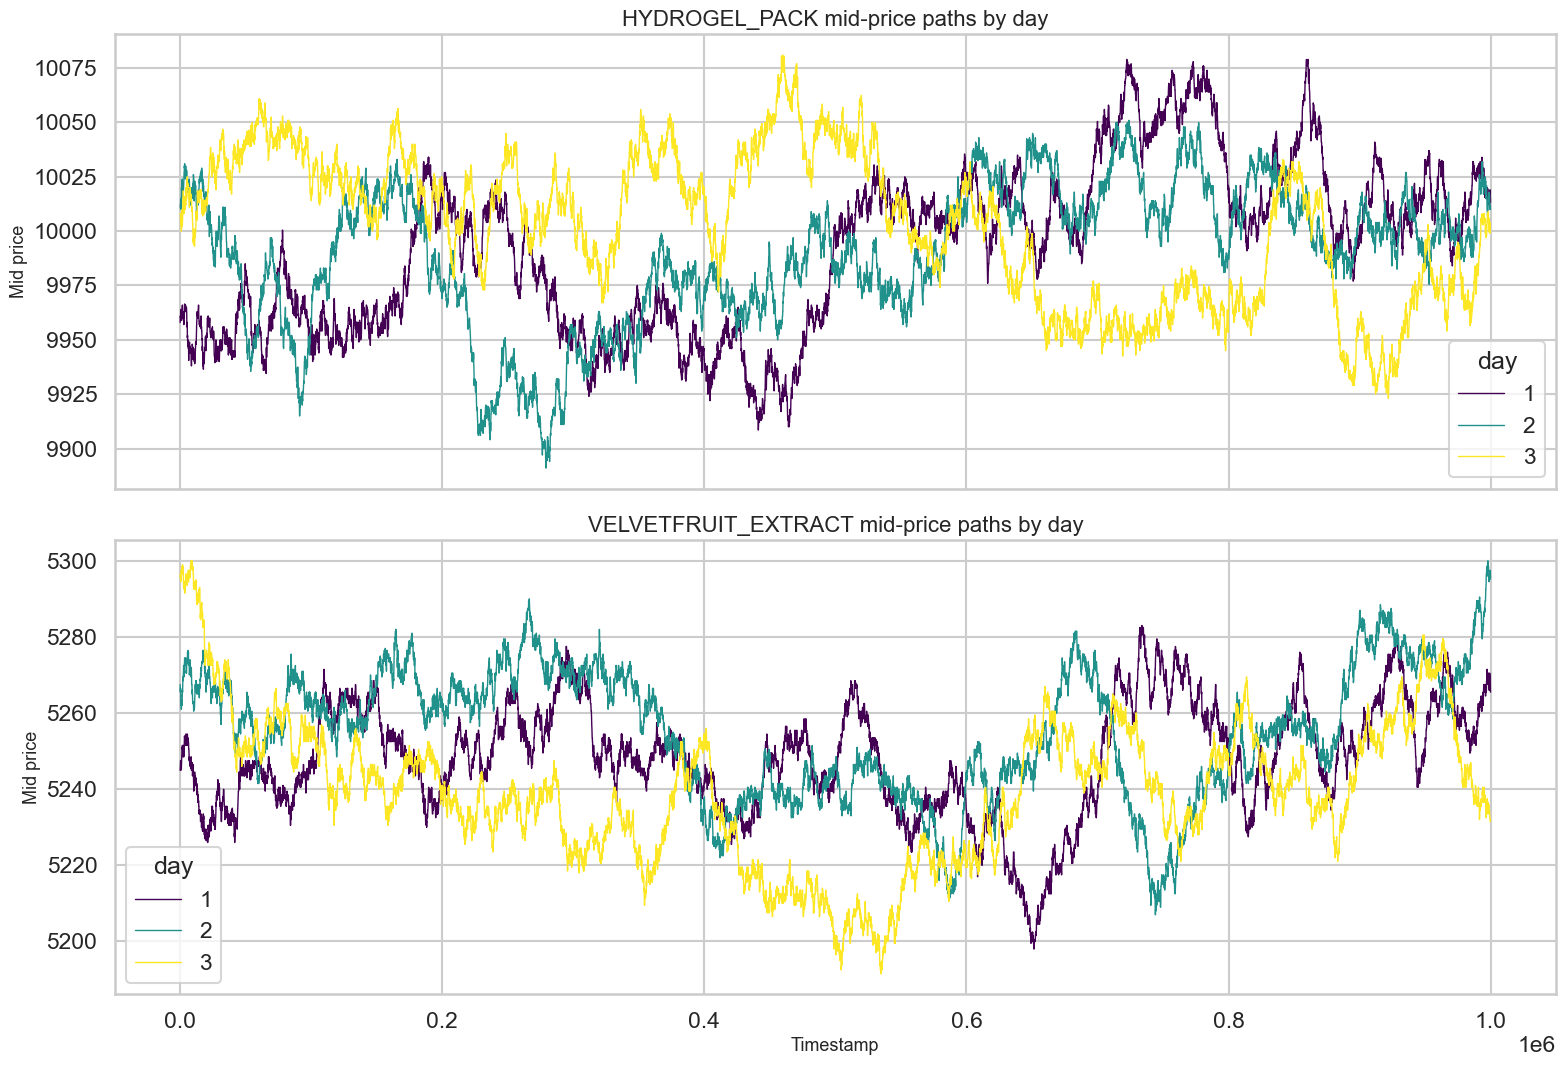

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
for ax, product in zip(axes, UNDERLYINGS):
    subset = prices[prices["product"] == product].copy()
    sns.lineplot(data=subset, x="timestamp", y="mid_price", hue="day", palette="viridis", linewidth=1, ax=ax)
    ax.set_title(f"{product} mid-price paths by day")
    ax.set_ylabel("Mid price")
    ax.legend(title="day")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
savefig("round4_underlying_price_paths.png")
plt.show()


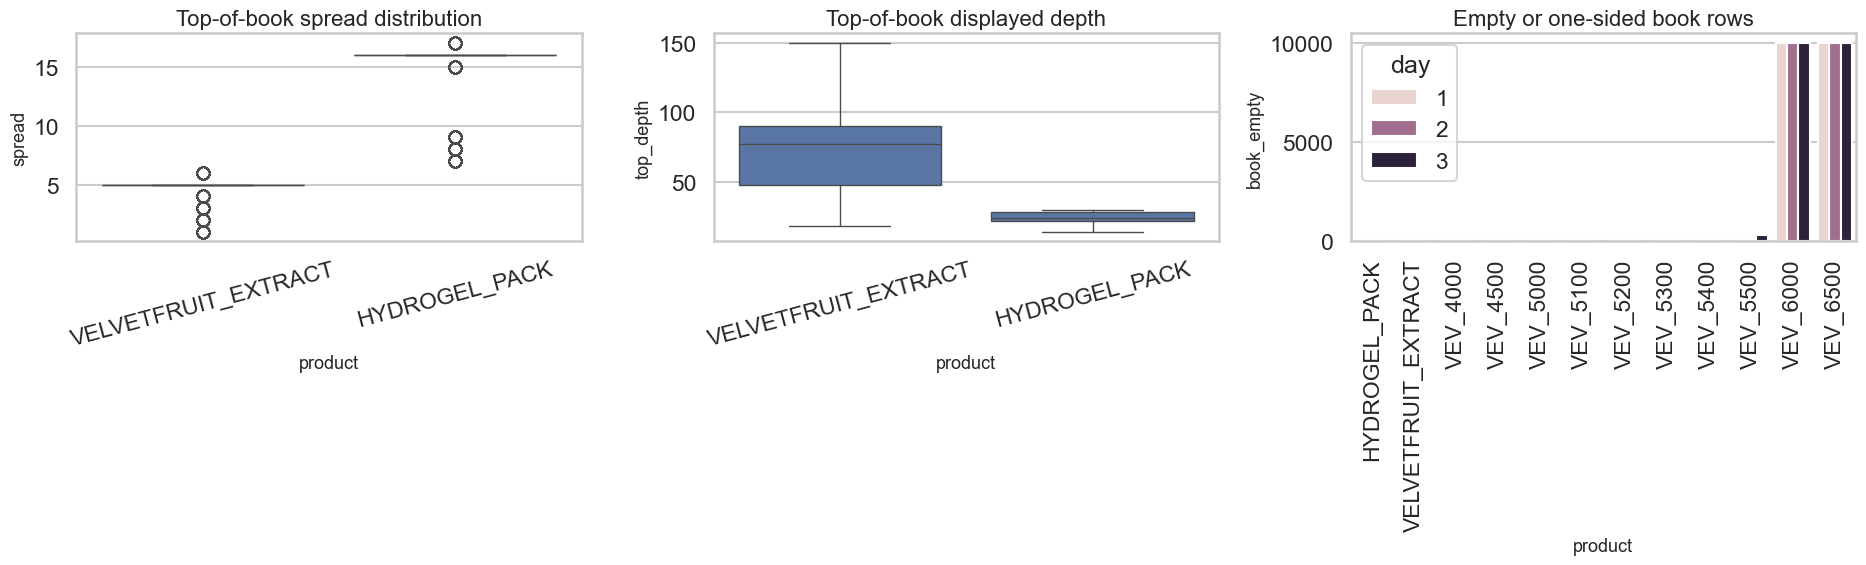

In [6]:
underlying = prices[prices["product"].isin(UNDERLYINGS)].copy()

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
sns.boxplot(data=underlying, x="product", y="spread", ax=axes[0])
axes[0].set_title("Top-of-book spread distribution")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=underlying, x="product", y="top_depth", ax=axes[1])
axes[1].set_title("Top-of-book displayed depth")
axes[1].tick_params(axis="x", rotation=15)

empty = prices.groupby(["product", "day"])["book_empty"].sum().reset_index()
sns.barplot(data=empty, x="product", y="book_empty", hue="day", ax=axes[2])
axes[2].set_title("Empty or one-sided book rows")
axes[2].tick_params(axis="x", rotation=90)
plt.tight_layout()
savefig("round4_liquidity_spread_depth_empty_books.png")
plt.show()


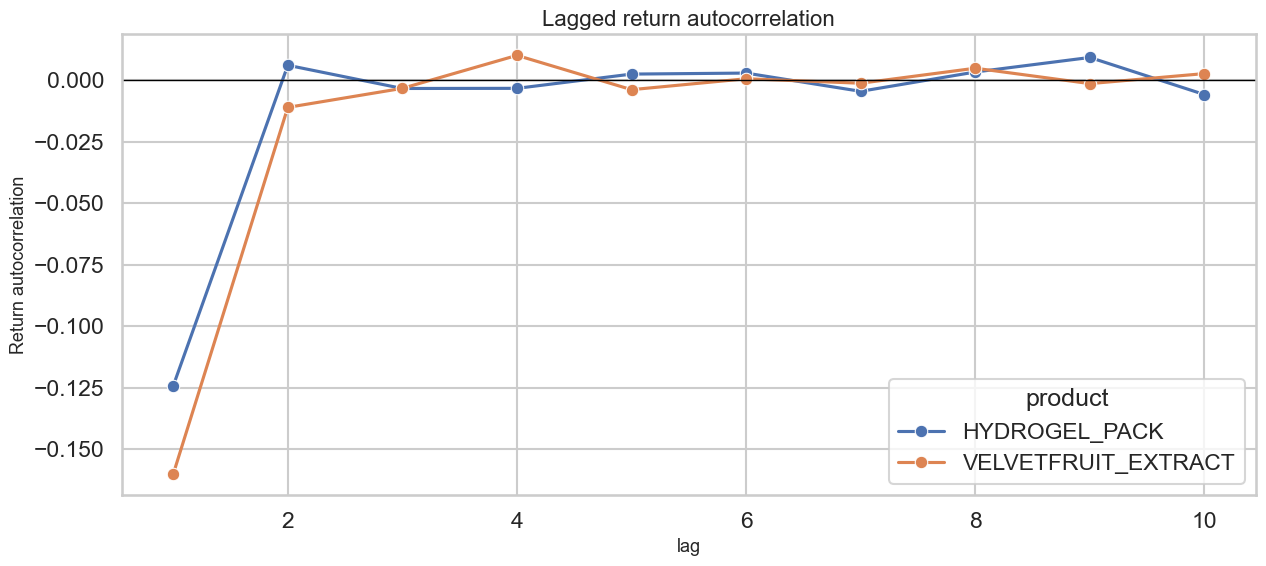

product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT
lag,,
1,-0.1242,-0.1601
2,0.0061,-0.0110
3,-0.0033,-0.0032
4,-0.0032,0.0102
5,0.0026,-0.0038
6,0.0030,0.0007
7,-0.0044,-0.0012
8,0.0034,0.0049
9,0.0093,-0.0013


In [7]:
wide_mid = prices.pivot_table(index=["day", "timestamp"], columns="product", values="mid_price")
returns = wide_mid.groupby(level=0).diff()

underlying_return_stats = []
for product in UNDERLYINGS:
    r = returns[product].dropna()
    for lag in range(1, 11):
        underlying_return_stats.append(
            {
                "product": product,
                "lag": lag,
                "autocorr": r.autocorr(lag),
            }
        )
autocorr_df = pd.DataFrame(underlying_return_stats)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=autocorr_df, x="lag", y="autocorr", hue="product", marker="o", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Lagged return autocorrelation")
ax.set_ylabel("Return autocorrelation")
plt.tight_layout()
savefig("round4_underlying_return_autocorrelation.png")
plt.show()

display(autocorr_df.pivot(index="lag", columns="product", values="autocorr").round(4))


,corr_imbalance_next_move,mean_next_move,std_next_move
product,,,
HYDROGEL_PACK,0.29935,0.00163,2.16893
VELVETFRUIT_EXTRACT,0.28084,-0.00050,1.13752


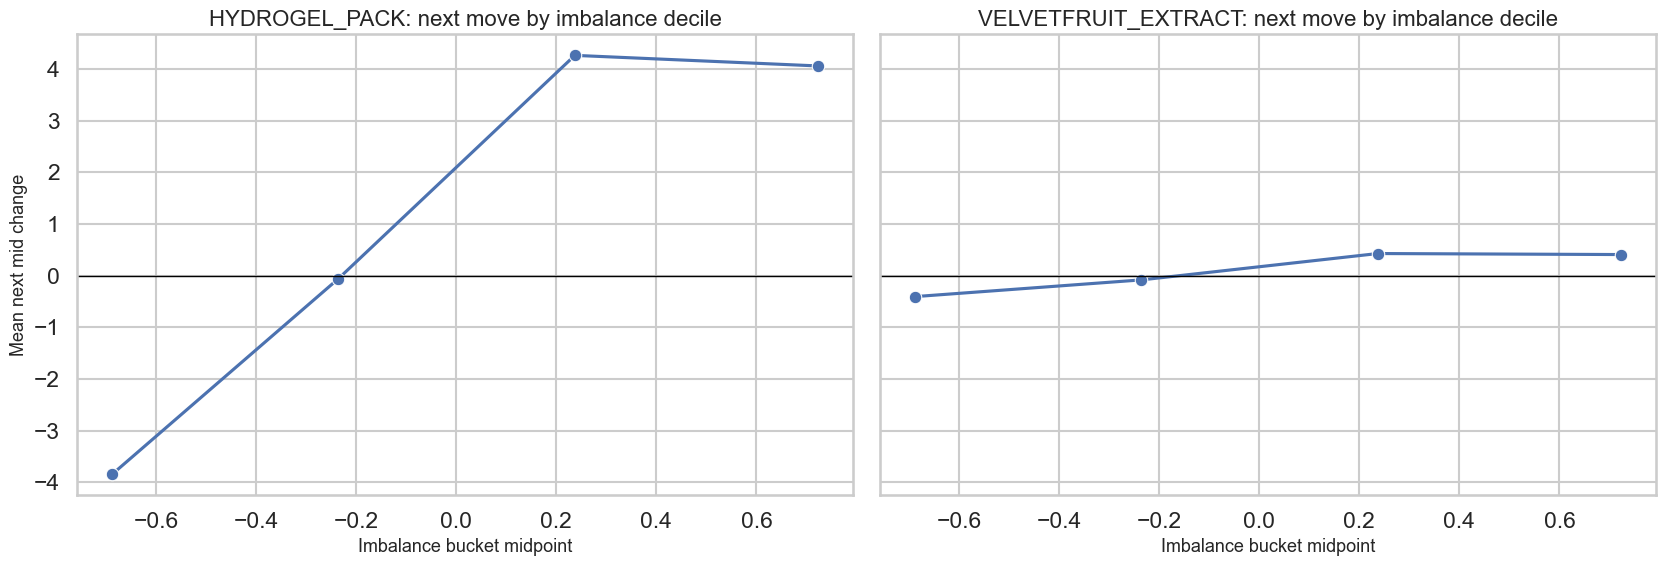

In [8]:
imbalance_rows = []
for product in UNDERLYINGS:
    df = prices[prices["product"] == product].sort_values(["day", "timestamp"]).copy()
    denom = df["bid_volume_1"].abs() + df["ask_volume_1"].abs()
    df["imbalance"] = np.where(denom > 0, (df["bid_volume_1"].fillna(0) - df["ask_volume_1"].abs().fillna(0)) / denom, np.nan)
    df["next_mid_change"] = df.groupby("day")["mid_price"].shift(-1) - df["mid_price"]
    df["product"] = product
    imbalance_rows.append(df[["day", "timestamp", "product", "imbalance", "next_mid_change"]])
imbalance = pd.concat(imbalance_rows, ignore_index=True).dropna()

imbalance_summary = imbalance.groupby("product").apply(
    lambda g: pd.Series(
        {
            "corr_imbalance_next_move": g["imbalance"].corr(g["next_mid_change"]),
            "mean_next_move": g["next_mid_change"].mean(),
            "std_next_move": g["next_mid_change"].std(),
        }
    )
)
display(imbalance_summary.round(5))

imbalance["bucket"] = pd.qcut(imbalance["imbalance"], 10, duplicates="drop")
bucketed = imbalance.groupby(["product", "bucket"], observed=True)["next_mid_change"].agg(["mean", "count"]).reset_index()
bucketed["bucket_mid"] = bucketed["bucket"].apply(lambda x: x.mid)

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)
for ax, product in zip(axes, UNDERLYINGS):
    sub = bucketed[bucketed["product"] == product]
    sns.lineplot(data=sub, x="bucket_mid", y="mean", marker="o", ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{product}: next move by imbalance decile")
    ax.set_xlabel("Imbalance bucket midpoint")
    ax.set_ylabel("Mean next mid change")
plt.tight_layout()
savefig("round4_imbalance_predictive_power.png")
plt.show()


### Delta-1 interpretation

This section should be used directly for the underlyings strategy:

- A negative lag-1 return autocorrelation supports taking stretched quotes back toward fair.
- A positive imbalance-to-next-move relationship supports skewing passive quotes with top-book imbalance.
- Spread and depth distributions define how far from fair we need to quote to avoid adverse selection.


## Trade And Counterparty Overview


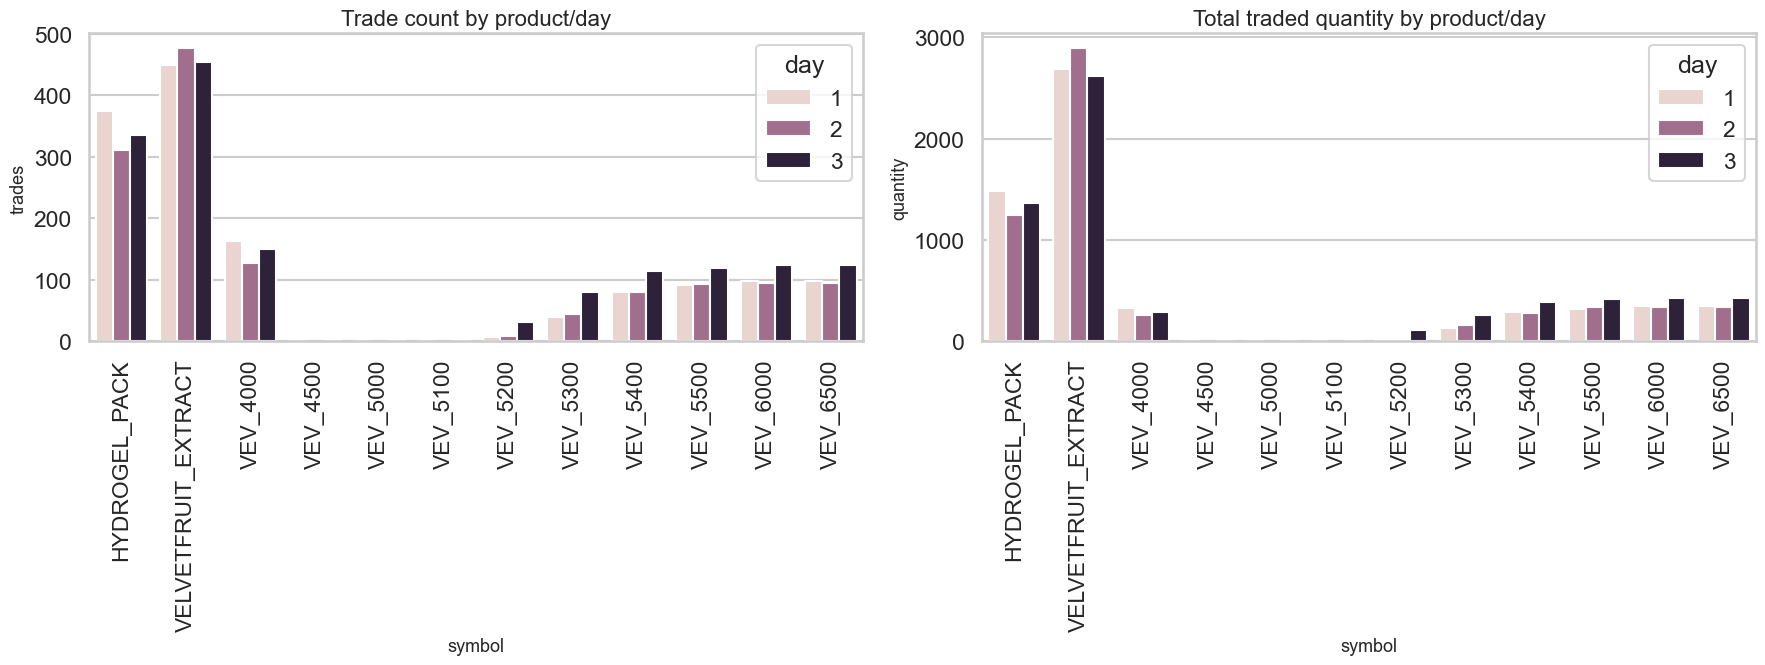

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
trade_counts = trades.groupby(["day", "symbol"]).size().reset_index(name="trades")
sns.barplot(data=trade_counts, x="symbol", y="trades", hue="day", ax=axes[0])
axes[0].set_title("Trade count by product/day")
axes[0].tick_params(axis="x", rotation=90)

trade_qty = trades.groupby(["day", "symbol"])["quantity"].sum().reset_index(name="quantity")
sns.barplot(data=trade_qty, x="symbol", y="quantity", hue="day", ax=axes[1])
axes[1].set_title("Total traded quantity by product/day")
axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
savefig("round4_trade_activity_by_product.png")
plt.show()


,gross_qty,net_abs_qty,trades,products
participant,,,,
Mark 14,8718.0,394.0,2172.0,7
Mark 01,7428.0,4678.0,1843.0,7
Mark 55,6551.0,43.0,1198.0,1
Mark 22,5889.0,5497.0,1584.0,12
Mark 38,5000.0,82.0,1478.0,7
Mark 67,1510.0,1510.0,165.0,1
Mark 49,1186.0,956.0,122.0,1


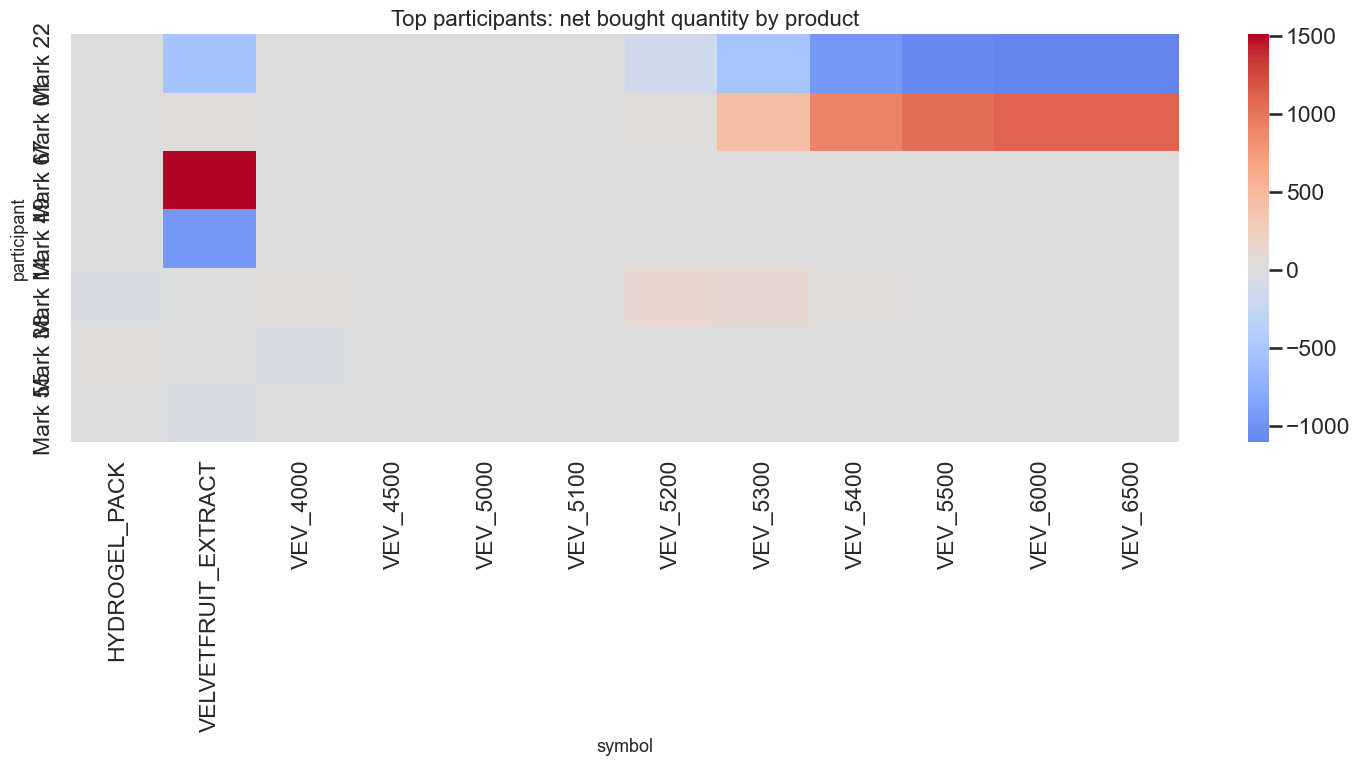

In [10]:
participants = sorted(set(trades["buyer"]) | set(trades["seller"]))

buyer_flow = trades.groupby(["buyer", "symbol"]).agg(
    buy_qty=("quantity", "sum"),
    buy_notional=("notional", "sum"),
    buy_trades=("quantity", "size"),
).reset_index().rename(columns={"buyer": "participant"})

seller_flow = trades.groupby(["seller", "symbol"]).agg(
    sell_qty=("quantity", "sum"),
    sell_notional=("notional", "sum"),
    sell_trades=("quantity", "size"),
).reset_index().rename(columns={"seller": "participant"})

flow = buyer_flow.merge(seller_flow, on=["participant", "symbol"], how="outer").fillna(0)
flow["net_qty"] = flow["buy_qty"] - flow["sell_qty"]
flow["gross_qty"] = flow["buy_qty"] + flow["sell_qty"]
flow["cashflow"] = flow["sell_notional"] - flow["buy_notional"]
flow["trades"] = flow["buy_trades"] + flow["sell_trades"]

top_flow = flow.groupby("participant").agg(
    gross_qty=("gross_qty", "sum"),
    net_abs_qty=("net_qty", lambda x: x.abs().sum()),
    trades=("trades", "sum"),
    products=("symbol", "nunique"),
).sort_values("gross_qty", ascending=False)

display(top_flow.head(20).round(2))

fig, ax = plt.subplots(figsize=(15, 8))
heat = flow.pivot_table(index="participant", columns="symbol", values="net_qty", aggfunc="sum", fill_value=0)
heat = heat.loc[heat.abs().sum(axis=1).sort_values(ascending=False).head(25).index, ALL_PRODUCTS]
sns.heatmap(heat, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Top participants: net bought quantity by product")
plt.tight_layout()
savefig("round4_counterparty_net_qty_heatmap.png")
plt.show()


,buyer,seller,trades,qty,notional
0,Mark 01,Mark 22,1339,4636,32427.0
3,Mark 14,Mark 38,728,2447,20434344.0
8,Mark 38,Mark 14,714,2445,20850351.0
13,Mark 55,Mark 14,331,1763,9254679.0
4,Mark 14,Mark 55,316,1761,9235831.0
1,Mark 01,Mark 55,260,1417,7432924.0
12,Mark 55,Mark 01,244,1375,7220079.0
17,Mark 67,Mark 49,89,963,5056558.0
16,Mark 67,Mark 22,75,546,2864651.0
2,Mark 14,Mark 22,83,302,14577.0


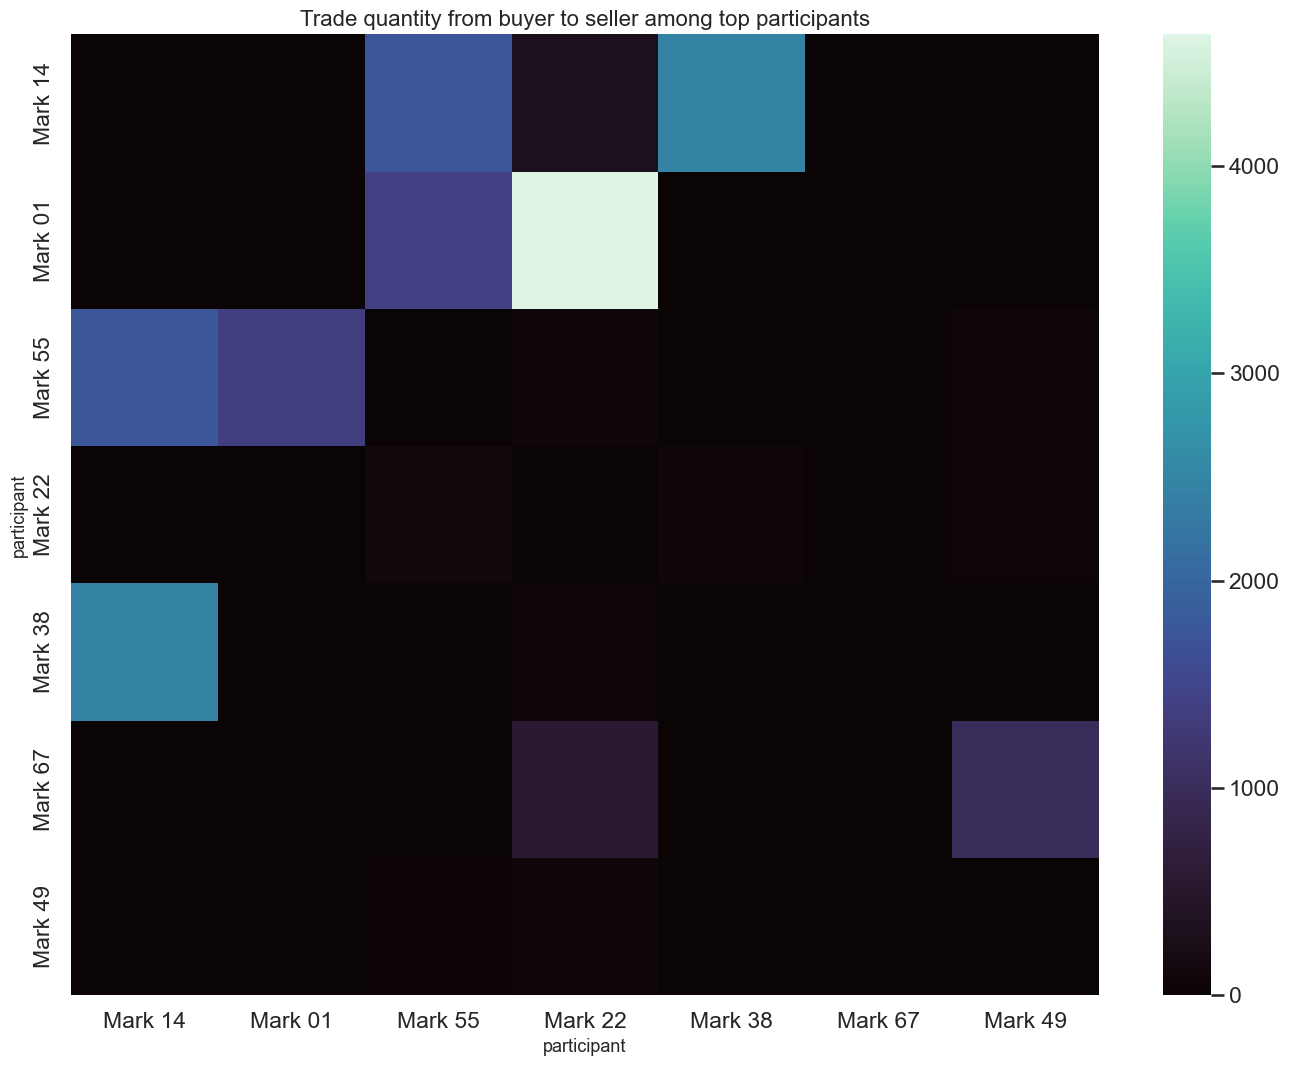

In [11]:
pair_flow = trades.groupby(["buyer", "seller"]).agg(
    trades=("quantity", "size"),
    qty=("quantity", "sum"),
    notional=("notional", "sum"),
).reset_index()

top_pairs = pair_flow.sort_values("qty", ascending=False).head(30)
display(top_pairs)

pair_matrix = pair_flow.pivot_table(index="buyer", columns="seller", values="qty", aggfunc="sum", fill_value=0)
top_ids = top_flow.head(20).index
pair_matrix = pair_matrix.reindex(index=top_ids, columns=top_ids).fillna(0)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(pair_matrix, cmap="mako", ax=ax)
ax.set_title("Trade quantity from buyer to seller among top participants")
plt.tight_layout()
savefig("round4_buyer_seller_pair_matrix.png")
plt.show()


## Counterparty Markout Analysis


In [12]:
trades_marked = add_future_mids_to_trades(trades, prices, horizons=(100, 500, 1000, 5000, 10000))

edge_rows = []
for h in [100, 500, 1000, 5000, 10000]:
    b = trades_marked.groupby(["buyer", "symbol"]).agg(
        edge=(f"buyer_edge_{h}", "mean"),
        edge_notional=(f"buyer_edge_notional_{h}", "sum"),
        qty=("quantity", "sum"),
        trades=("quantity", "size"),
    ).reset_index().rename(columns={"buyer": "participant"})
    b["side"] = "buyer"
    b["horizon"] = h

    s = trades_marked.groupby(["seller", "symbol"]).agg(
        edge=(f"seller_edge_{h}", "mean"),
        edge_notional=(f"seller_edge_notional_{h}", "sum"),
        qty=("quantity", "sum"),
        trades=("quantity", "size"),
    ).reset_index().rename(columns={"seller": "participant"})
    s["side"] = "seller"
    s["horizon"] = h
    edge_rows.append(pd.concat([b, s], ignore_index=True))

edges = pd.concat(edge_rows, ignore_index=True).dropna(subset=["edge"])
edges["edge_per_unit"] = edges["edge_notional"] / edges["qty"].replace(0, np.nan)

edge_summary_1000 = edges[(edges["horizon"] == 1000) & (edges["trades"] >= 5)].copy()
display(edge_summary_1000.sort_values("edge_per_unit", ascending=False).head(30).round(3))
display(edge_summary_1000.sort_values("edge_per_unit", ascending=True).head(30).round(3))

edges.to_csv(ANALYSED_DIR / "round4_counterparty_markout_edges.csv", index=False)


,participant,symbol,edge,edge_notional,qty,trades,side,horizon,edge_per_unit
123,Mark 14,VEV_4000,10.537,4821.0,458,232,buyer,1000,10.526
149,Mark 14,VEV_4000,10.126,4178.5,412,207,seller,1000,10.142
121,Mark 14,HYDROGEL_PACK,8.213,16198.0,1989,496,buyer,1000,8.144
147,Mark 14,HYDROGEL_PACK,8.052,16080.5,2033,507,seller,1000,7.910
146,Mark 01,VELVETFRUIT_EXTRACT,3.000,4108.5,1375,244,seller,1000,2.988
114,Mark 01,VELVETFRUIT_EXTRACT,2.837,4028.5,1417,260,buyer,1000,2.843
115,Mark 01,VEV_5200,1.955,76.5,34,11,buyer,1000,2.250
148,Mark 14,VELVETFRUIT_EXTRACT,2.295,3927.0,1763,331,seller,1000,2.227
122,Mark 14,VELVETFRUIT_EXTRACT,2.176,3703.5,1761,316,buyer,1000,2.103
145,Mark 67,VELVETFRUIT_EXTRACT,1.445,2176.0,1510,165,buyer,1000,1.441


,participant,symbol,edge,edge_notional,qty,trades,side,horizon,edge_per_unit
163,Mark 38,VEV_4000,-10.511,-4834.5,461,233,seller,1000,-10.487
137,Mark 38,VEV_4000,-10.048,-4186.0,415,209,buyer,1000,-10.087
162,Mark 38,HYDROGEL_PACK,-8.015,-16197.0,2031,507,seller,1000,-7.975
136,Mark 38,HYDROGEL_PACK,-7.929,-16092.5,2065,515,buyer,1000,-7.793
144,Mark 55,VELVETFRUIT_EXTRACT,-2.482,-8011.0,3254,598,buyer,1000,-2.462
170,Mark 55,VELVETFRUIT_EXTRACT,-2.428,-7855.5,3297,600,seller,1000,-2.383
169,Mark 49,VELVETFRUIT_EXTRACT,-1.471,-1644.5,1071,105,seller,1000,-1.535
156,Mark 22,VEV_5200,-1.022,-170.0,159,46,seller,1000,-1.069
151,Mark 22,VELVETFRUIT_EXTRACT,-0.851,-584.0,697,101,seller,1000,-0.838
157,Mark 22,VEV_5300,-0.727,-398.5,545,163,seller,1000,-0.731


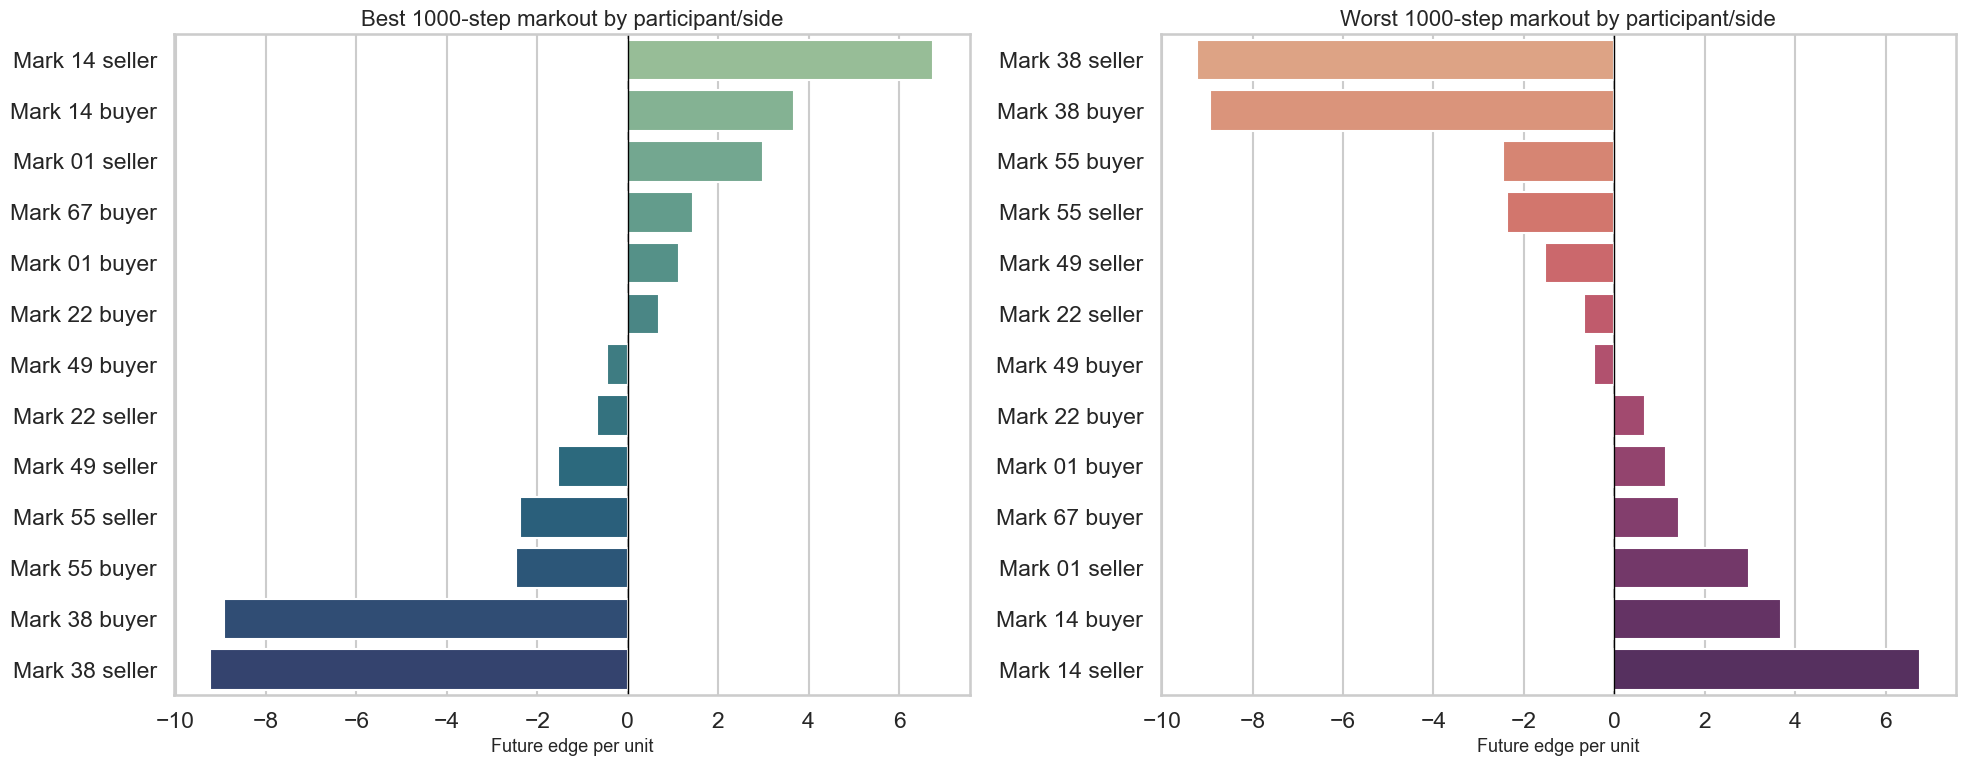

In [13]:
participant_edge = edges[(edges["horizon"] == 1000) & (edges["trades"] >= 10)].groupby(["participant", "side"]).agg(
    edge_per_unit=("edge_per_unit", "mean"),
    edge_notional=("edge_notional", "sum"),
    trades=("trades", "sum"),
    qty=("qty", "sum"),
).reset_index()

participant_edge["label"] = participant_edge["participant"] + " " + participant_edge["side"]
best = participant_edge.sort_values("edge_per_unit", ascending=False).head(20)
worst = participant_edge.sort_values("edge_per_unit", ascending=True).head(20)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=False)
sns.barplot(data=best, y="label", x="edge_per_unit", ax=axes[0], palette="crest")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Best 1000-step markout by participant/side")
axes[0].set_xlabel("Future edge per unit")
axes[0].set_ylabel("")

sns.barplot(data=worst, y="label", x="edge_per_unit", ax=axes[1], palette="flare")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Worst 1000-step markout by participant/side")
axes[1].set_xlabel("Future edge per unit")
axes[1].set_ylabel("")
plt.tight_layout()
savefig("round4_counterparty_best_worst_markouts.png")
plt.show()


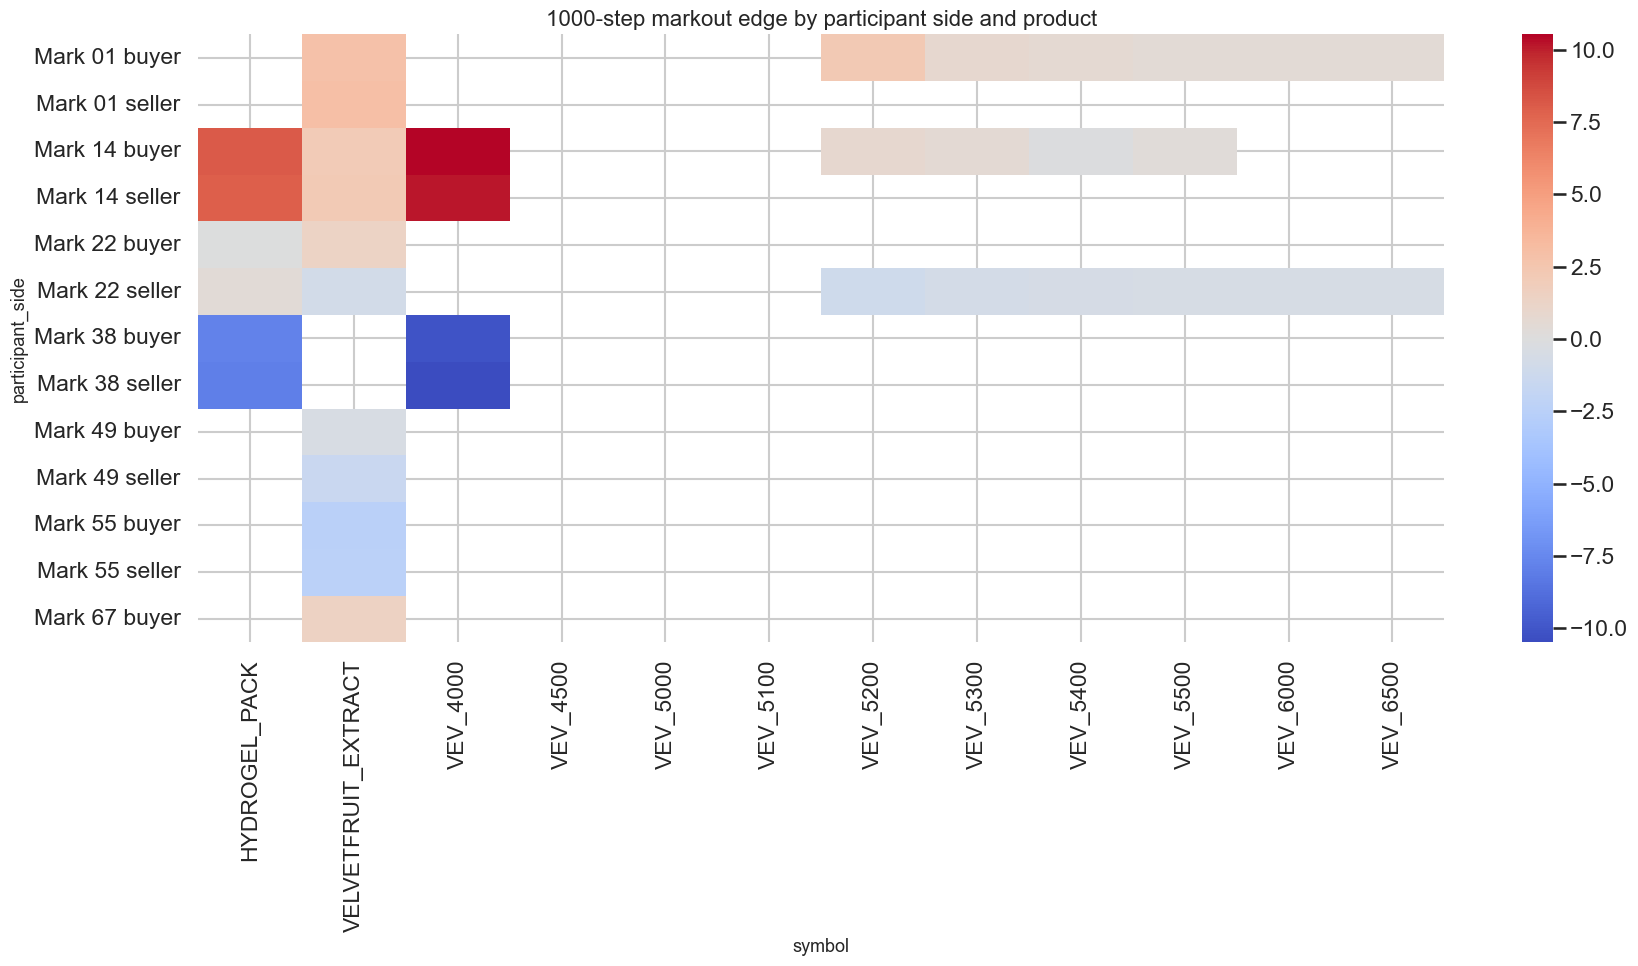

In [14]:
product_edge = edges[(edges["horizon"] == 1000) & (edges["trades"] >= 3)].copy()
product_edge["participant_side"] = product_edge["participant"] + " " + product_edge["side"]

ranked_ids = (
    product_edge.groupby("participant_side")["edge_notional"].sum()
    .abs()
    .sort_values(ascending=False)
    .head(25)
    .index
)

heat = product_edge[product_edge["participant_side"].isin(ranked_ids)].pivot_table(
    index="participant_side",
    columns="symbol",
    values="edge_per_unit",
    aggfunc="mean",
)
heat = heat.reindex(columns=ALL_PRODUCTS)

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(heat, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("1000-step markout edge by participant side and product")
plt.tight_layout()
savefig("round4_counterparty_product_edge_heatmap.png")
plt.show()


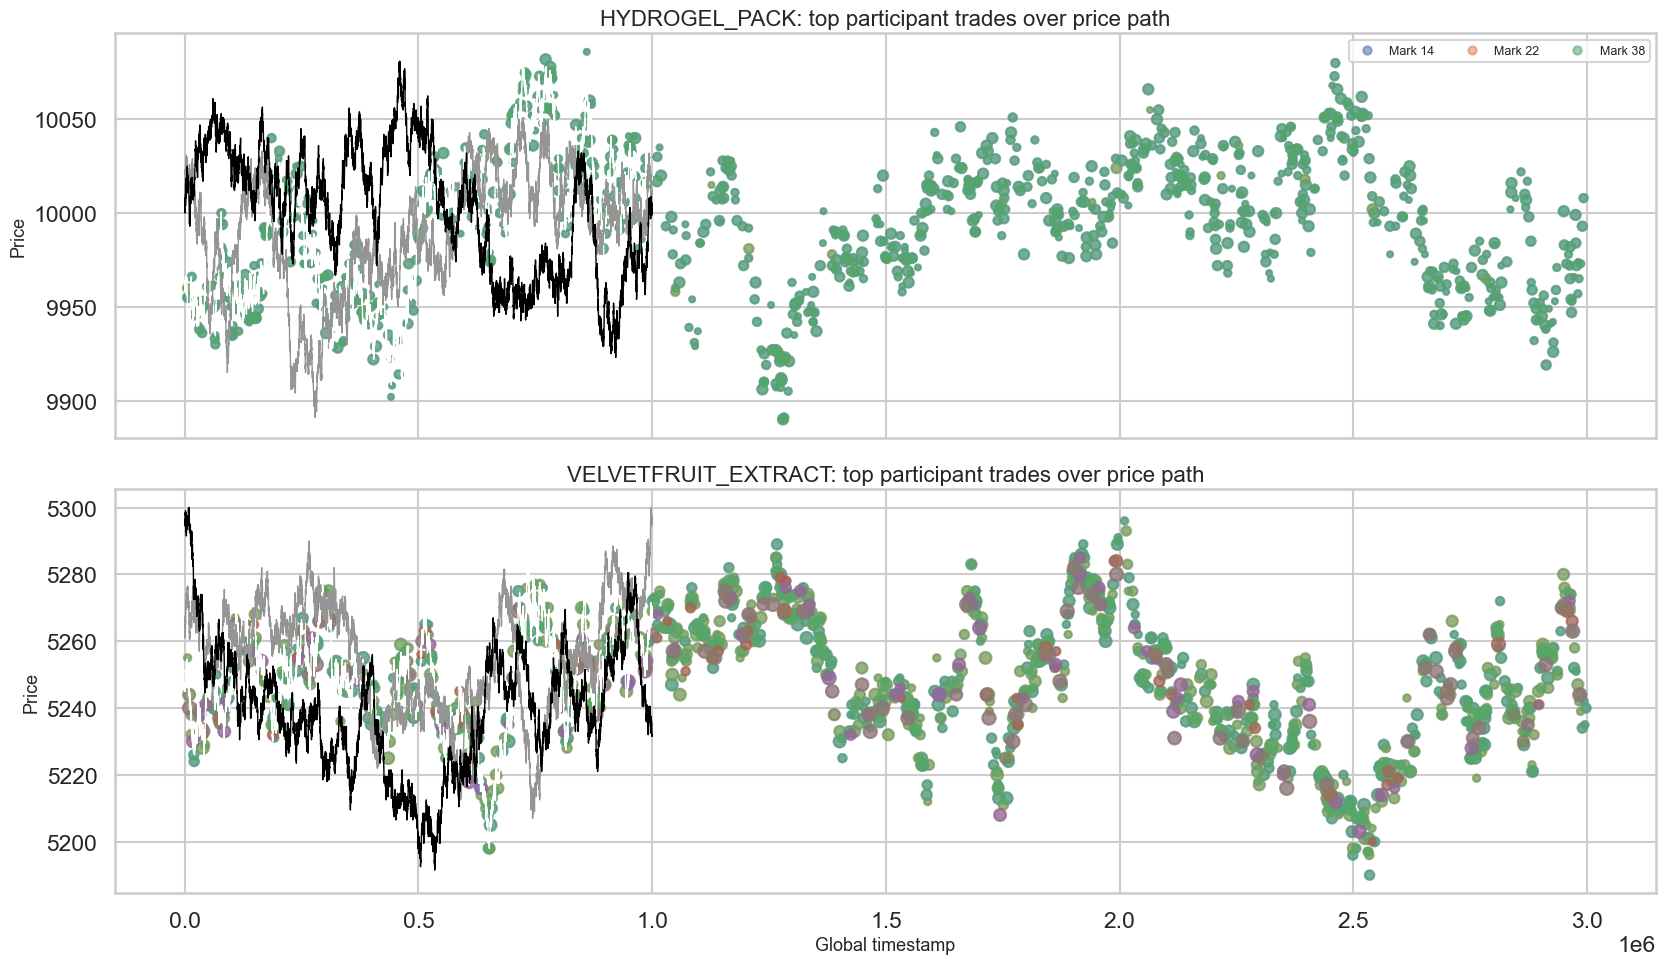

In [15]:
focus_marks = top_flow.head(8).index.tolist()
fig, axes = plt.subplots(len(UNDERLYINGS), 1, figsize=(17, 10), sharex=True)
for ax, product in zip(axes, UNDERLYINGS):
    px = prices[prices["product"] == product]
    sns.lineplot(data=px, x="global_timestamp", y="mid_price", hue="day", palette="Greys", legend=False, linewidth=1, ax=ax)
    for mark in focus_marks:
        sub = trades[((trades["buyer"] == mark) | (trades["seller"] == mark)) & (trades["symbol"] == product)].copy()
        if sub.empty:
            continue
        sub["signed_qty"] = np.where(sub["buyer"] == mark, sub["quantity"], -sub["quantity"])
        ax.scatter(
            sub["global_timestamp"],
            sub["price"],
            s=np.clip(sub["quantity"] * 9, 15, 90),
            alpha=0.55,
            label=mark,
        )
    ax.set_title(f"{product}: top participant trades over price path")
    ax.set_ylabel("Price")
axes[-1].set_xlabel("Global timestamp")
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles[:10], labels[:10], ncol=5, fontsize=9)
plt.tight_layout()
savefig("round4_top_marks_trade_overlays.png")
plt.show()


### Counterparty interpretation

The `edge_per_unit` metric is the cleanest first-pass signal:

- Buyer edge at horizon `h`: `future_mid - trade_price`
- Seller edge at horizon `h`: `trade_price - future_mid`

Positive values mean that participant/side was directionally right after the trade. A trader can use this in two ways:

1. Follow good counterparties: if a strong positive-edge buyer just bought, bias fair value upward or buy with them.
2. Fade weak counterparties: if a consistently negative-edge buyer just bought, treat the print as less informative or even contrarian.

This is not automatically a full strategy. It must be gated by product, horizon, and minimum sample size because some marks only trade a few times.


## Voucher Surface And Option Signals


In [16]:
options = prices[prices["product"].isin(VOUCHERS)].copy()
underlying_mid = prices[prices["product"] == "VELVETFRUIT_EXTRACT"][["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "S"})
options = options.merge(underlying_mid, on=["day", "timestamp"], how="left")
options["strike"] = options["product"].map(STRIKES).astype(int)
options["intrinsic"] = np.maximum(options["S"] - options["strike"], 0)
options["extrinsic"] = options["mid_price"] - options["intrinsic"]
options["moneyness"] = options["S"] / options["strike"]

chain_summary = options.groupby("product").agg(
    strike=("strike", "first"),
    mean_mid=("mid_price", "mean"),
    mean_intrinsic=("intrinsic", "mean"),
    mean_extrinsic=("extrinsic", "mean"),
    mean_spread=("spread", "mean"),
    mean_top_depth=("top_depth", "mean"),
    empty_rows=("book_empty", "sum"),
).sort_values("strike")
display(chain_summary.round(3))


,strike,mean_mid,mean_intrinsic,mean_extrinsic,mean_spread,mean_top_depth,empty_rows
product,,,,,,,
VEV_4000,4000,1247.657,1247.649,0.008,20.754,21.830,0
VEV_4500,4500,747.657,747.649,0.008,15.794,17.898,0
VEV_5000,5000,251.145,247.649,3.496,5.964,31.208,0
VEV_5100,5100,160.863,147.649,13.215,4.174,39.121,0
VEV_5200,5200,88.993,47.662,41.332,2.758,45.618,0
VEV_5300,5300,41.176,0.000,41.176,1.973,41.048,0
VEV_5400,5400,12.630,0.000,12.630,1.304,43.782,0
VEV_5500,5500,4.708,0.000,4.708,1.109,44.561,299
VEV_6000,6000,0.500,0.000,0.500,NaN,44.974,30000


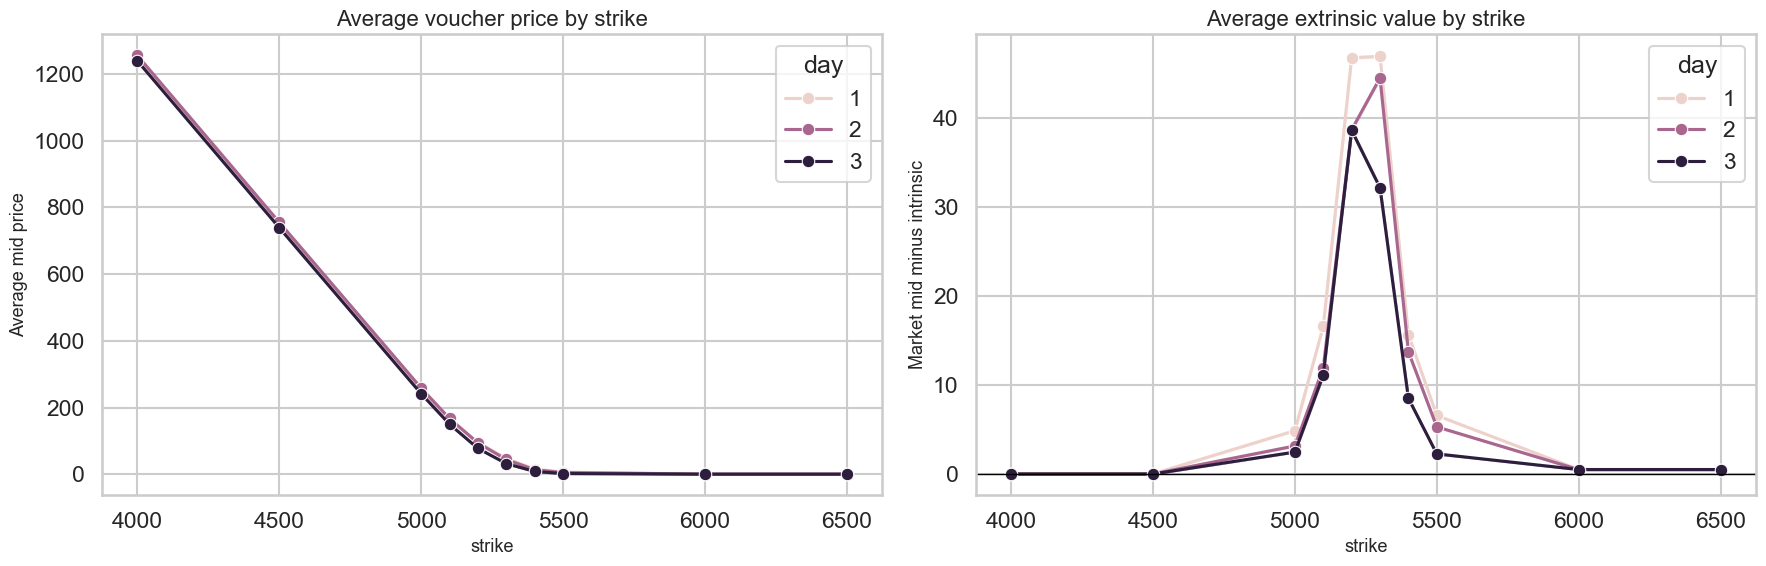

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(data=options, x="strike", y="mid_price", hue="day", estimator="mean", marker="o", ax=axes[0])
axes[0].set_title("Average voucher price by strike")
axes[0].set_ylabel("Average mid price")

sns.lineplot(data=options, x="strike", y="extrinsic", hue="day", estimator="mean", marker="o", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Average extrinsic value by strike")
axes[1].set_ylabel("Market mid minus intrinsic")
plt.tight_layout()
savefig("round4_voucher_price_and_extrinsic_by_strike.png")
plt.show()


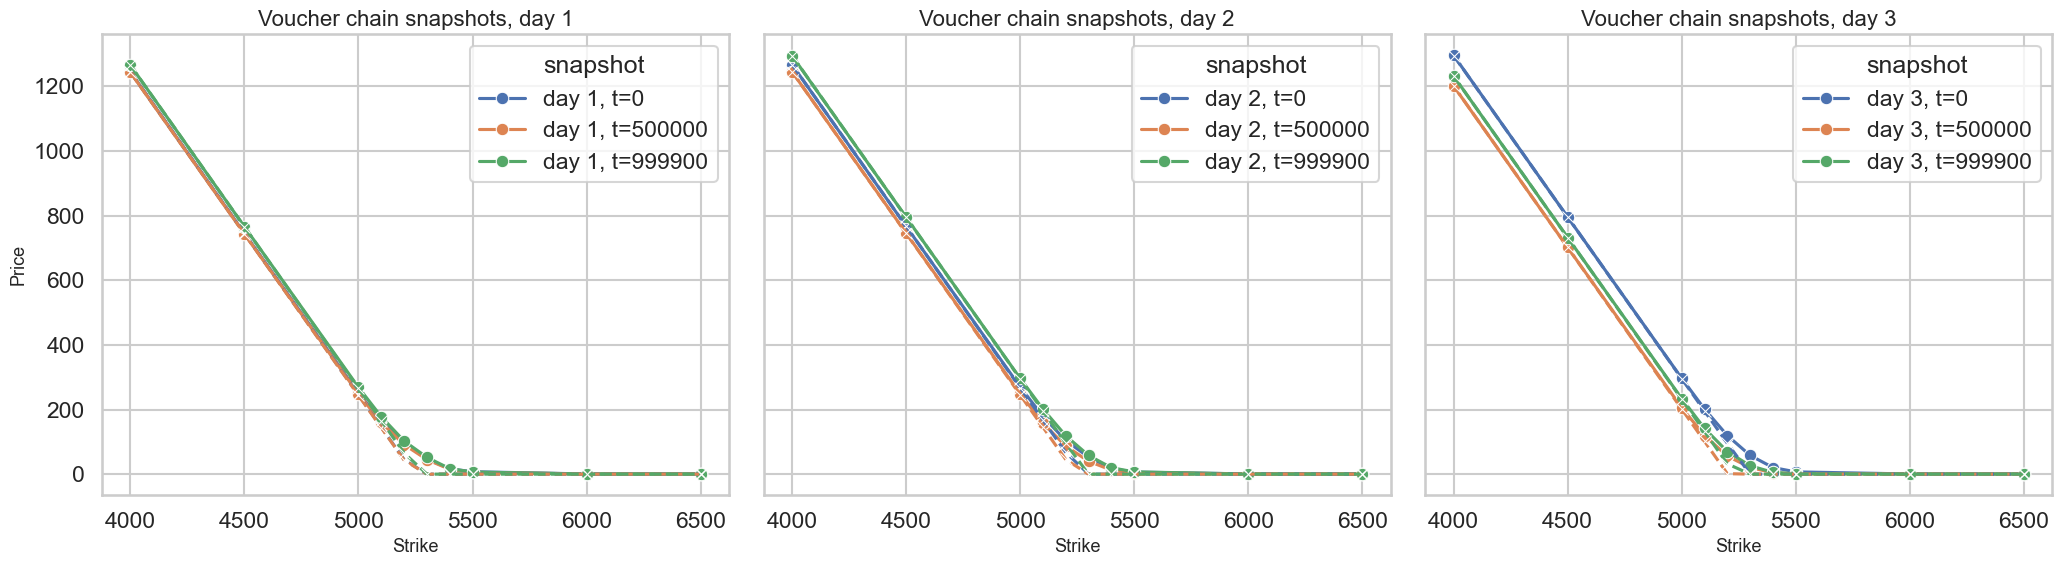

In [18]:
snapshot_rows = []
for day in sorted(options["day"].unique()):
    ts_values = np.sort(options.loc[options["day"] == day, "timestamp"].unique())
    for ts in [ts_values[0], ts_values[len(ts_values)//2], ts_values[-1]]:
        chain = options[(options["day"] == day) & (options["timestamp"] == ts)].sort_values("strike")
        snapshot_rows.append(chain.assign(snapshot=f"day {day}, t={ts}"))
snapshots = pd.concat(snapshot_rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for ax, day in zip(axes, sorted(options["day"].unique())):
    sub = snapshots[snapshots["day"] == day]
    sns.lineplot(data=sub, x="strike", y="mid_price", hue="snapshot", marker="o", ax=ax)
    sns.lineplot(data=sub, x="strike", y="intrinsic", hue="snapshot", marker="x", linestyle="--", ax=ax, legend=False)
    ax.set_title(f"Voucher chain snapshots, day {day}")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Price")
plt.tight_layout()
savefig("round4_voucher_chain_snapshots.png")
plt.show()


monotone_violations     convex_violations     min_extrinsic     
                   mean max              mean max          mean  max
day                                                                 
1                   0.0   0            0.0000   0       -0.2128  0.5
2                   0.0   0            0.0000   0       -0.1907  0.5
3                   0.0   0            0.0006   1       -0.2149  0.5

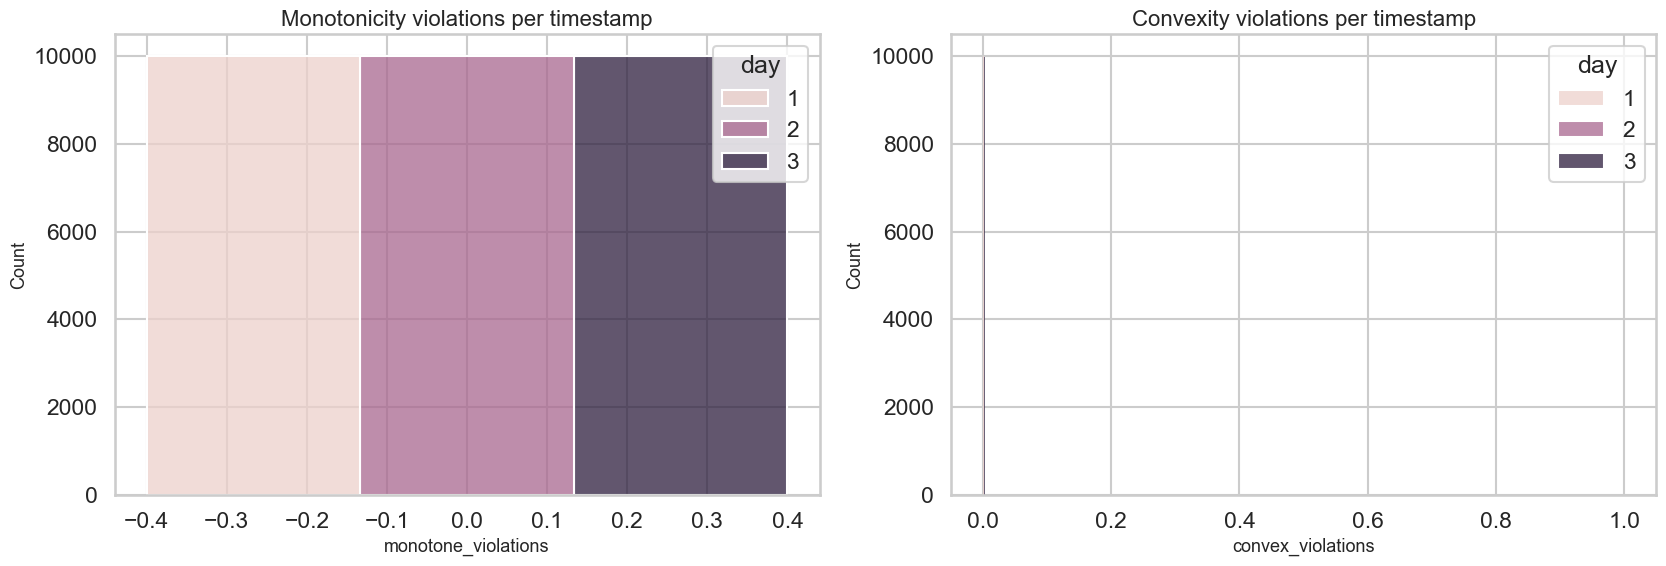

In [19]:
arb_rows = []
for (day, ts), grp in options.groupby(["day", "timestamp"]):
    chain = grp.sort_values("strike")
    mids = chain["mid_price"].to_numpy()
    strikes = chain["strike"].to_numpy()
    monotone_violations = int(np.sum(np.diff(mids) > 1e-9))
    convex_violations = int(np.sum(np.diff(mids, n=2) < -1e-9))
    arb_rows.append(
        {
            "day": day,
            "timestamp": ts,
            "monotone_violations": monotone_violations,
            "convex_violations": convex_violations,
            "min_extrinsic": float(chain["extrinsic"].min()),
            "max_extrinsic": float(chain["extrinsic"].max()),
        }
    )
arb = pd.DataFrame(arb_rows)
display(arb.groupby("day")[["monotone_violations", "convex_violations", "min_extrinsic"]].agg(["mean", "max"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.histplot(data=arb, x="monotone_violations", hue="day", multiple="dodge", shrink=0.8, ax=axes[0])
axes[0].set_title("Monotonicity violations per timestamp")
sns.histplot(data=arb, x="convex_violations", hue="day", multiple="dodge", shrink=0.8, ax=axes[1])
axes[1].set_title("Convexity violations per timestamp")
plt.tight_layout()
savefig("round4_voucher_static_arbitrage_checks.png")
plt.show()


In [20]:
fit_rows = []
for day in sorted(options["day"].unique()):
    ts_values = np.sort(options.loc[options["day"] == day, "timestamp"].unique())
    for ts in ts_values[::25]:
        chain = options[(options["day"] == day) & (options["timestamp"] == ts)].sort_values("strike").copy()
        S = float(chain["S"].iloc[0])
        strikes = chain["strike"].to_numpy(dtype=float)
        market = chain["mid_price"].to_numpy(dtype=float)
        sigma, model = best_fit_sigma(S, strikes, market, T=T_MAIN)
        for product, strike, market_price, model_price in zip(chain["product"], chain["strike"], market, model):
            fit_rows.append(
                {
                    "day": day,
                    "timestamp": ts,
                    "S": S,
                    "sigma": sigma,
                    "product": product,
                    "strike": int(strike),
                    "market_mid": float(market_price),
                    "model_price": float(model_price),
                    "residual": float(market_price - model_price),
                }
            )
fit_sample = pd.DataFrame(fit_rows)
display(fit_sample.groupby("day")["sigma"].agg(["mean", "std", "min", "max"]).round(4))
fit_sample.to_csv(ANALYSED_DIR / "round4_voucher_bs_fit_sample.csv", index=False)


,mean,std,min,max
day,,,,
1,0.3086,0.0070,0.2918,0.3217
2,0.2833,0.0081,0.2662,0.3003
3,0.2551,0.0090,0.2363,0.2747


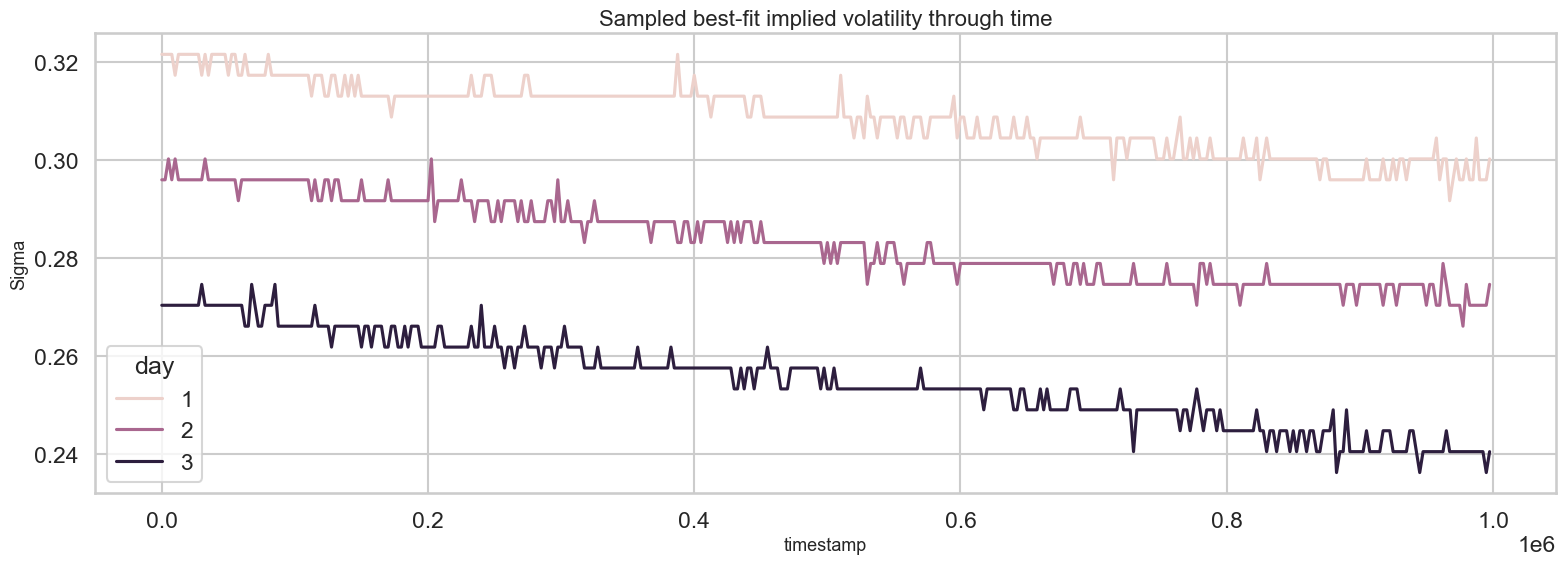

In [21]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(data=fit_sample[["day", "timestamp", "sigma"]].drop_duplicates(), x="timestamp", y="sigma", hue="day", ax=ax)
ax.set_title("Sampled best-fit implied volatility through time")
ax.set_ylabel("Sigma")
plt.tight_layout()
savefig("round4_sampled_implied_vol.png")
plt.show()


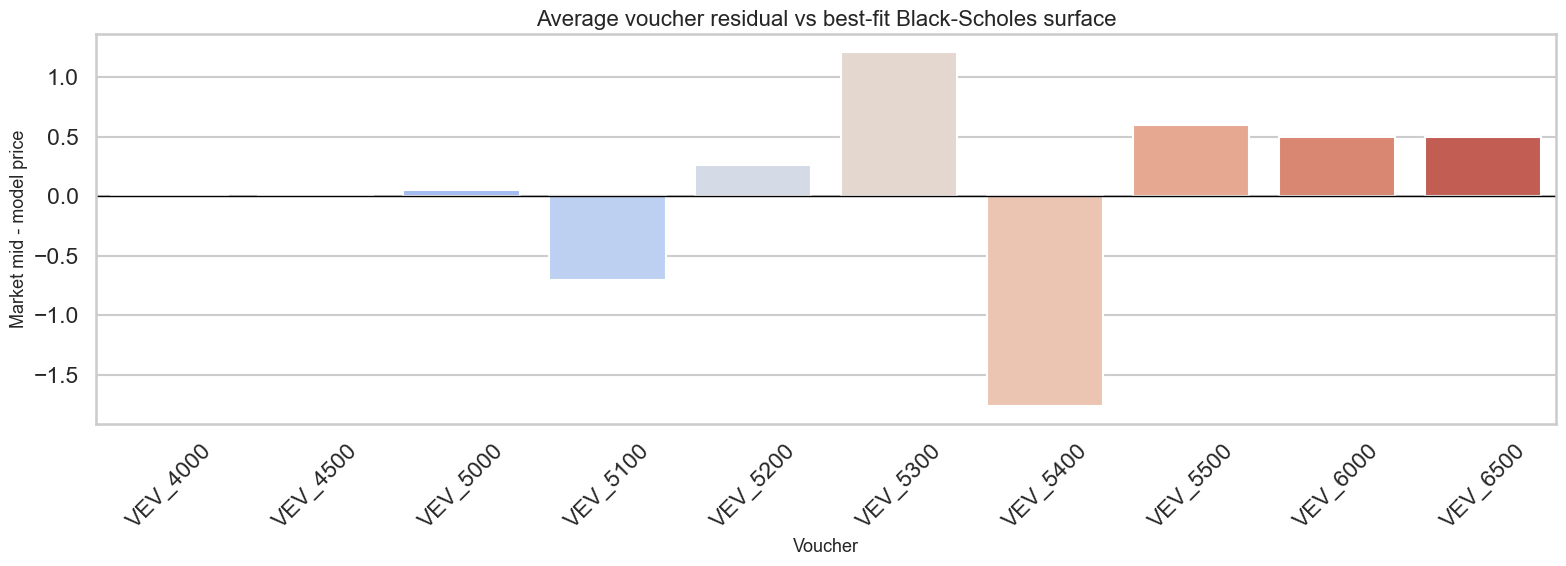

,strike,mean_residual,median_residual,std_residual,mean_market,mean_model
product,,,,,,
VEV_4000,4000,0.0163,0.0000,0.8724,1247.7675,1247.7512
VEV_4500,4500,0.0012,-0.0000,0.7702,747.7525,747.7513
VEV_5000,5000,0.0558,0.0439,0.5138,251.2338,251.1780
VEV_5100,5100,-0.7027,-0.6805,0.5690,160.9358,161.6386
VEV_5200,5200,0.2637,0.2366,0.5303,89.0483,88.7847
VEV_5300,5300,1.2118,1.1624,0.6474,41.2079,39.9961
VEV_5400,5400,-1.7601,-1.7502,0.8266,12.6496,14.4097
VEV_5500,5500,0.6033,0.5901,0.4592,4.7229,4.1196
VEV_6000,6000,0.4997,0.4999,0.0004,0.5000,0.0003


In [22]:
residual_summary = fit_sample.groupby("product").agg(
    strike=("strike", "first"),
    mean_residual=("residual", "mean"),
    median_residual=("residual", "median"),
    std_residual=("residual", "std"),
    mean_market=("market_mid", "mean"),
    mean_model=("model_price", "mean"),
).sort_values("strike")

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=residual_summary.reset_index(), x="product", y="mean_residual", palette="coolwarm", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Average voucher residual vs best-fit Black-Scholes surface")
ax.set_xlabel("Voucher")
ax.set_ylabel("Market mid - model price")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
savefig("round4_voucher_model_residuals.png")
plt.show()

display(residual_summary.round(4))


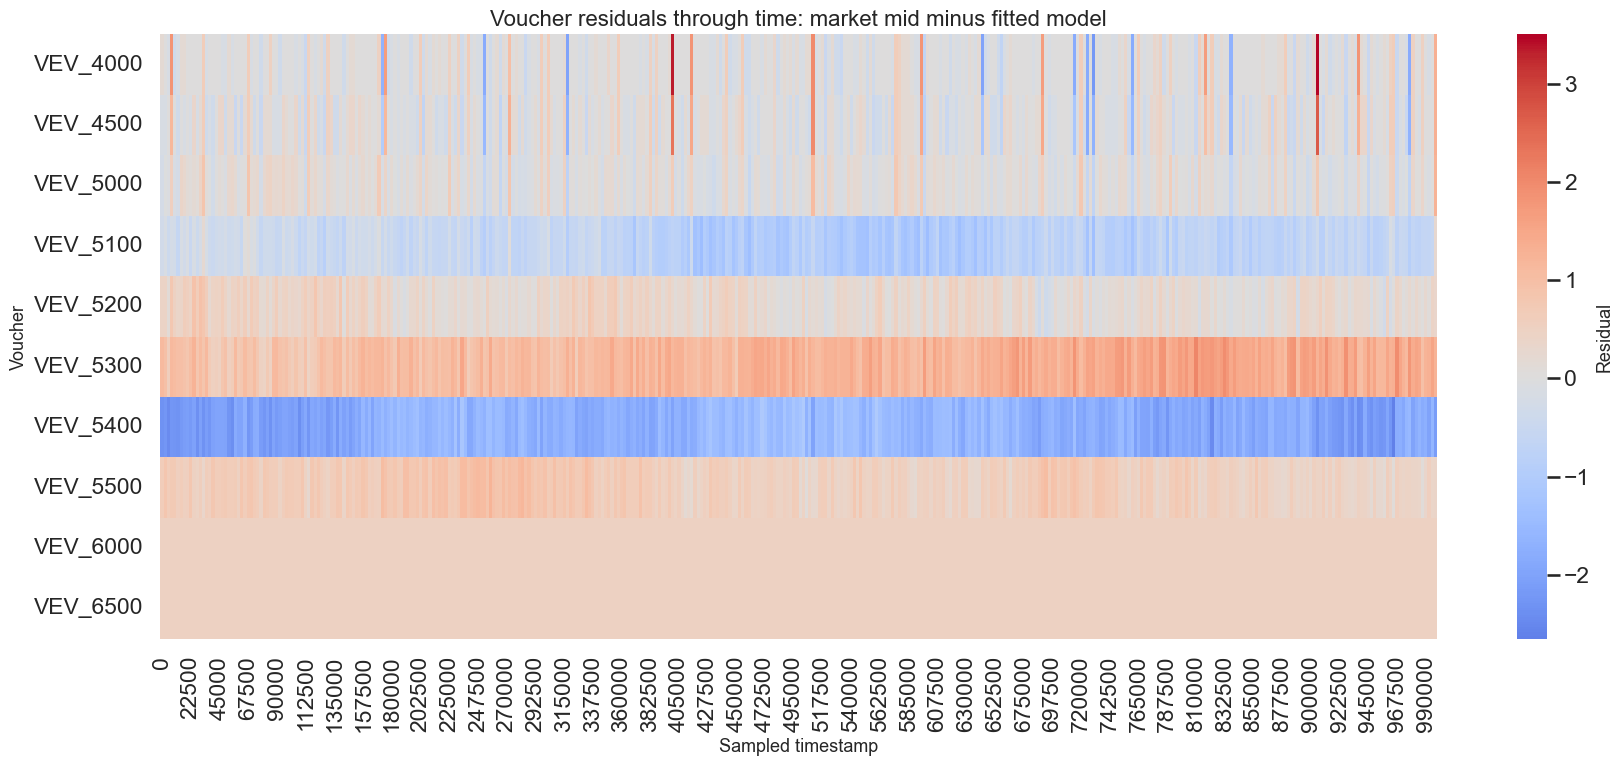

In [23]:
resid_pivot = fit_sample.pivot_table(index="timestamp", columns="product", values="residual", aggfunc="mean")
resid_pivot = resid_pivot[VOUCHERS]
fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(resid_pivot.T, cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Residual"})
ax.set_title("Voucher residuals through time: market mid minus fitted model")
ax.set_xlabel("Sampled timestamp")
ax.set_ylabel("Voucher")
plt.tight_layout()
savefig("round4_voucher_residual_heatmap.png")
plt.show()


sigma            rmse        
          mean     std    mean     std
T_days                                
2       0.3996  0.0330  0.9079  0.3681
3       0.3261  0.0270  0.9116  0.3666
4       0.2825  0.0233  0.9142  0.3664
5       0.2525  0.0209  0.9182  0.3652
6       0.2307  0.0191  0.9215  0.3640

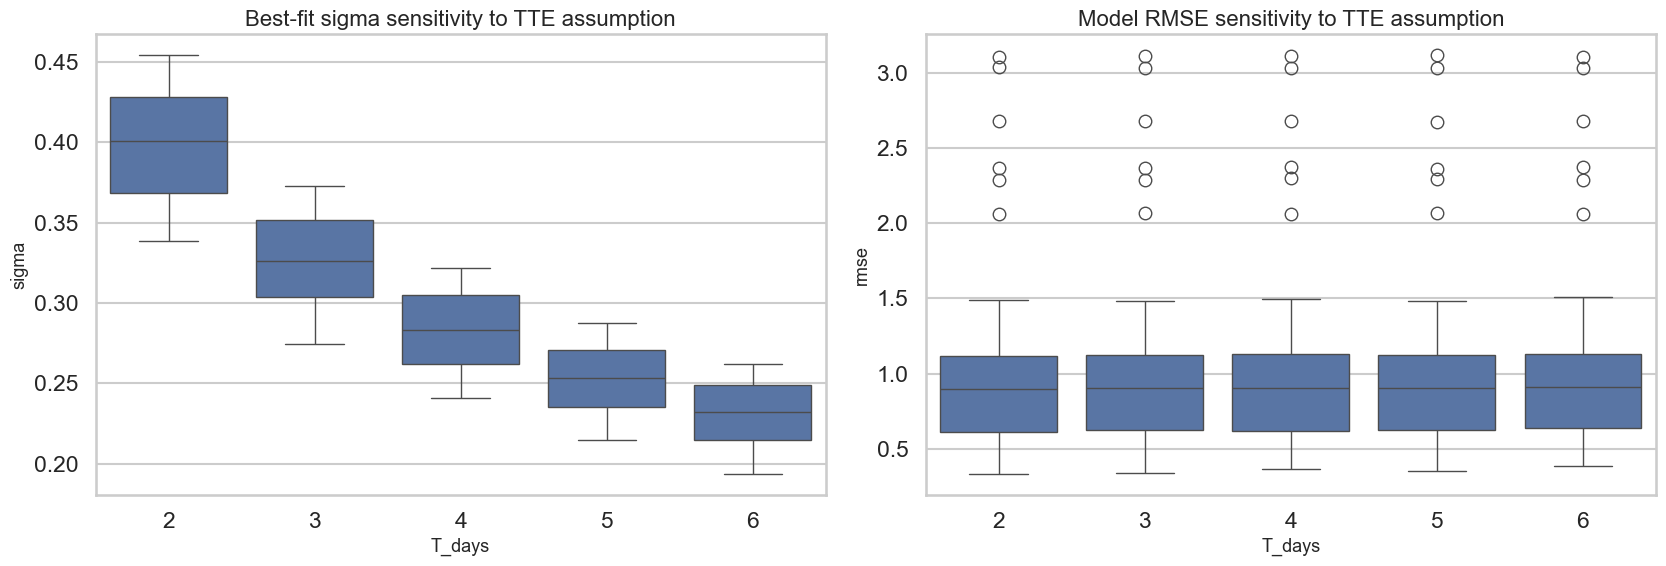

In [24]:
tte_sensitivity = []
for T_days in [2, 3, 4, 5, 6]:
    rows = []
    for day in sorted(options["day"].unique()):
        ts_values = np.sort(options.loc[options["day"] == day, "timestamp"].unique())
        for ts in ts_values[::100]:
            chain = options[(options["day"] == day) & (options["timestamp"] == ts)].sort_values("strike")
            sigma, model = best_fit_sigma(
                float(chain["S"].iloc[0]),
                chain["strike"].to_numpy(dtype=float),
                chain["mid_price"].to_numpy(dtype=float),
                T=T_days / 365,
            )
            rows.append({"T_days": T_days, "day": day, "timestamp": ts, "sigma": sigma, "rmse": float(np.sqrt(((model - chain["mid_price"].to_numpy()) ** 2).mean()))})
    tte_sensitivity.append(pd.DataFrame(rows))
tte_sensitivity = pd.concat(tte_sensitivity, ignore_index=True)

display(tte_sensitivity.groupby("T_days")[["sigma", "rmse"]].agg(["mean", "std"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.boxplot(data=tte_sensitivity, x="T_days", y="sigma", ax=axes[0])
axes[0].set_title("Best-fit sigma sensitivity to TTE assumption")
sns.boxplot(data=tte_sensitivity, x="T_days", y="rmse", ax=axes[1])
axes[1].set_title("Model RMSE sensitivity to TTE assumption")
plt.tight_layout()
savefig("round4_tte_sensitivity.png")
plt.show()


### Voucher interpretation

The fitted surface is not meant to be a perfect options model. It is a compact way to detect cross-sectional mispricing. The most useful outputs are:

- stable or unstable fitted sigma through time,
- residuals by strike,
- residual heatmaps that show whether a voucher is persistently rich or cheap,
- static-arbitrage checks for monotonicity and convexity.

For implementation, do not overfit every residual. Prefer persistent, repeated residuals in liquid strikes or strikes with obvious model structure.


## Combined Signal Candidates


In [25]:
# Build a lightweight table of candidate signals that could be implemented in trader.py.
signal_rows = []

for product in UNDERLYINGS:
    s = imbalance_summary.loc[product]
    ac1 = autocorr_df[(autocorr_df["product"] == product) & (autocorr_df["lag"] == 1)]["autocorr"].iloc[0]
    signal_rows.append(
        {
            "asset": product,
            "signal": "mean reversion + top-book imbalance",
            "evidence": f"lag1 autocorr={ac1:.3f}, imbalance corr={s['corr_imbalance_next_move']:.3f}",
            "implementation_hint": "skew fair value with imbalance; take stretched quotes around rolling/anchored fair",
            "risk": "inventory at empty-book or regime-change timestamps",
        }
    )

for product, row in residual_summary.iterrows():
    if abs(row["mean_residual"]) >= 2:
        side = "sell rich" if row["mean_residual"] > 0 else "buy cheap"
        signal_rows.append(
            {
                "asset": product,
                "signal": f"voucher residual: {side}",
                "evidence": f"mean residual={row['mean_residual']:.2f}, std={row['std_residual']:.2f}",
                "implementation_hint": "compare live voucher mid/bid/ask to fitted surface and trade only with edge buffer",
                "risk": "surface fit error, delta exposure to VELVETFRUIT_EXTRACT",
            }
        )

edge_candidates = edge_summary_1000[(edge_summary_1000["trades"] >= 5) & (edge_summary_1000["edge_per_unit"].abs() >= 1.0)].copy()
for _, row in edge_candidates.sort_values("edge_per_unit", key=lambda x: x.abs(), ascending=False).head(15).iterrows():
    direction = "follow" if row["edge_per_unit"] > 0 else "fade"
    signal_rows.append(
        {
            "asset": row["symbol"],
            "signal": f"{direction} {row['participant']} as {row['side']}",
            "evidence": f"1000-step edge/unit={row['edge_per_unit']:.2f}, trades={int(row['trades'])}",
            "implementation_hint": "adjust fair value for a few ticks after this participant-side appears in market_trades",
            "risk": "sample size and same-participant behavior may shift in final",
        }
    )

signal_table = pd.DataFrame(signal_rows)
display(signal_table)
signal_table.to_csv(ANALYSED_DIR / "round4_signal_candidates.csv", index=False)


,asset,signal,evidence,implementation_hint,risk
0,HYDROGEL_PACK,mean reversion + top-book imbalance,"lag1 autocorr=-0.124, imbalance corr=0.299",skew fair value with imbalance; take stretched...,inventory at empty-book or regime-change times...
1,VELVETFRUIT_EXTRACT,mean reversion + top-book imbalance,"lag1 autocorr=-0.160, imbalance corr=0.281",skew fair value with imbalance; take stretched...,inventory at empty-book or regime-change times...
2,VEV_4000,follow Mark 14 as buyer,"1000-step edge/unit=10.53, trades=232",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...
3,VEV_4000,fade Mark 38 as seller,"1000-step edge/unit=-10.49, trades=233",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...
4,VEV_4000,follow Mark 14 as seller,"1000-step edge/unit=10.14, trades=207",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...
5,VEV_4000,fade Mark 38 as buyer,"1000-step edge/unit=-10.09, trades=209",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...
6,HYDROGEL_PACK,follow Mark 14 as buyer,"1000-step edge/unit=8.14, trades=496",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...
7,HYDROGEL_PACK,fade Mark 38 as seller,"1000-step edge/unit=-7.97, trades=507",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...
8,HYDROGEL_PACK,follow Mark 14 as seller,"1000-step edge/unit=7.91, trades=507",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...
9,HYDROGEL_PACK,fade Mark 38 as buyer,"1000-step edge/unit=-7.79, trades=515",adjust fair value for a few ticks after this p...,sample size and same-participant behavior may ...


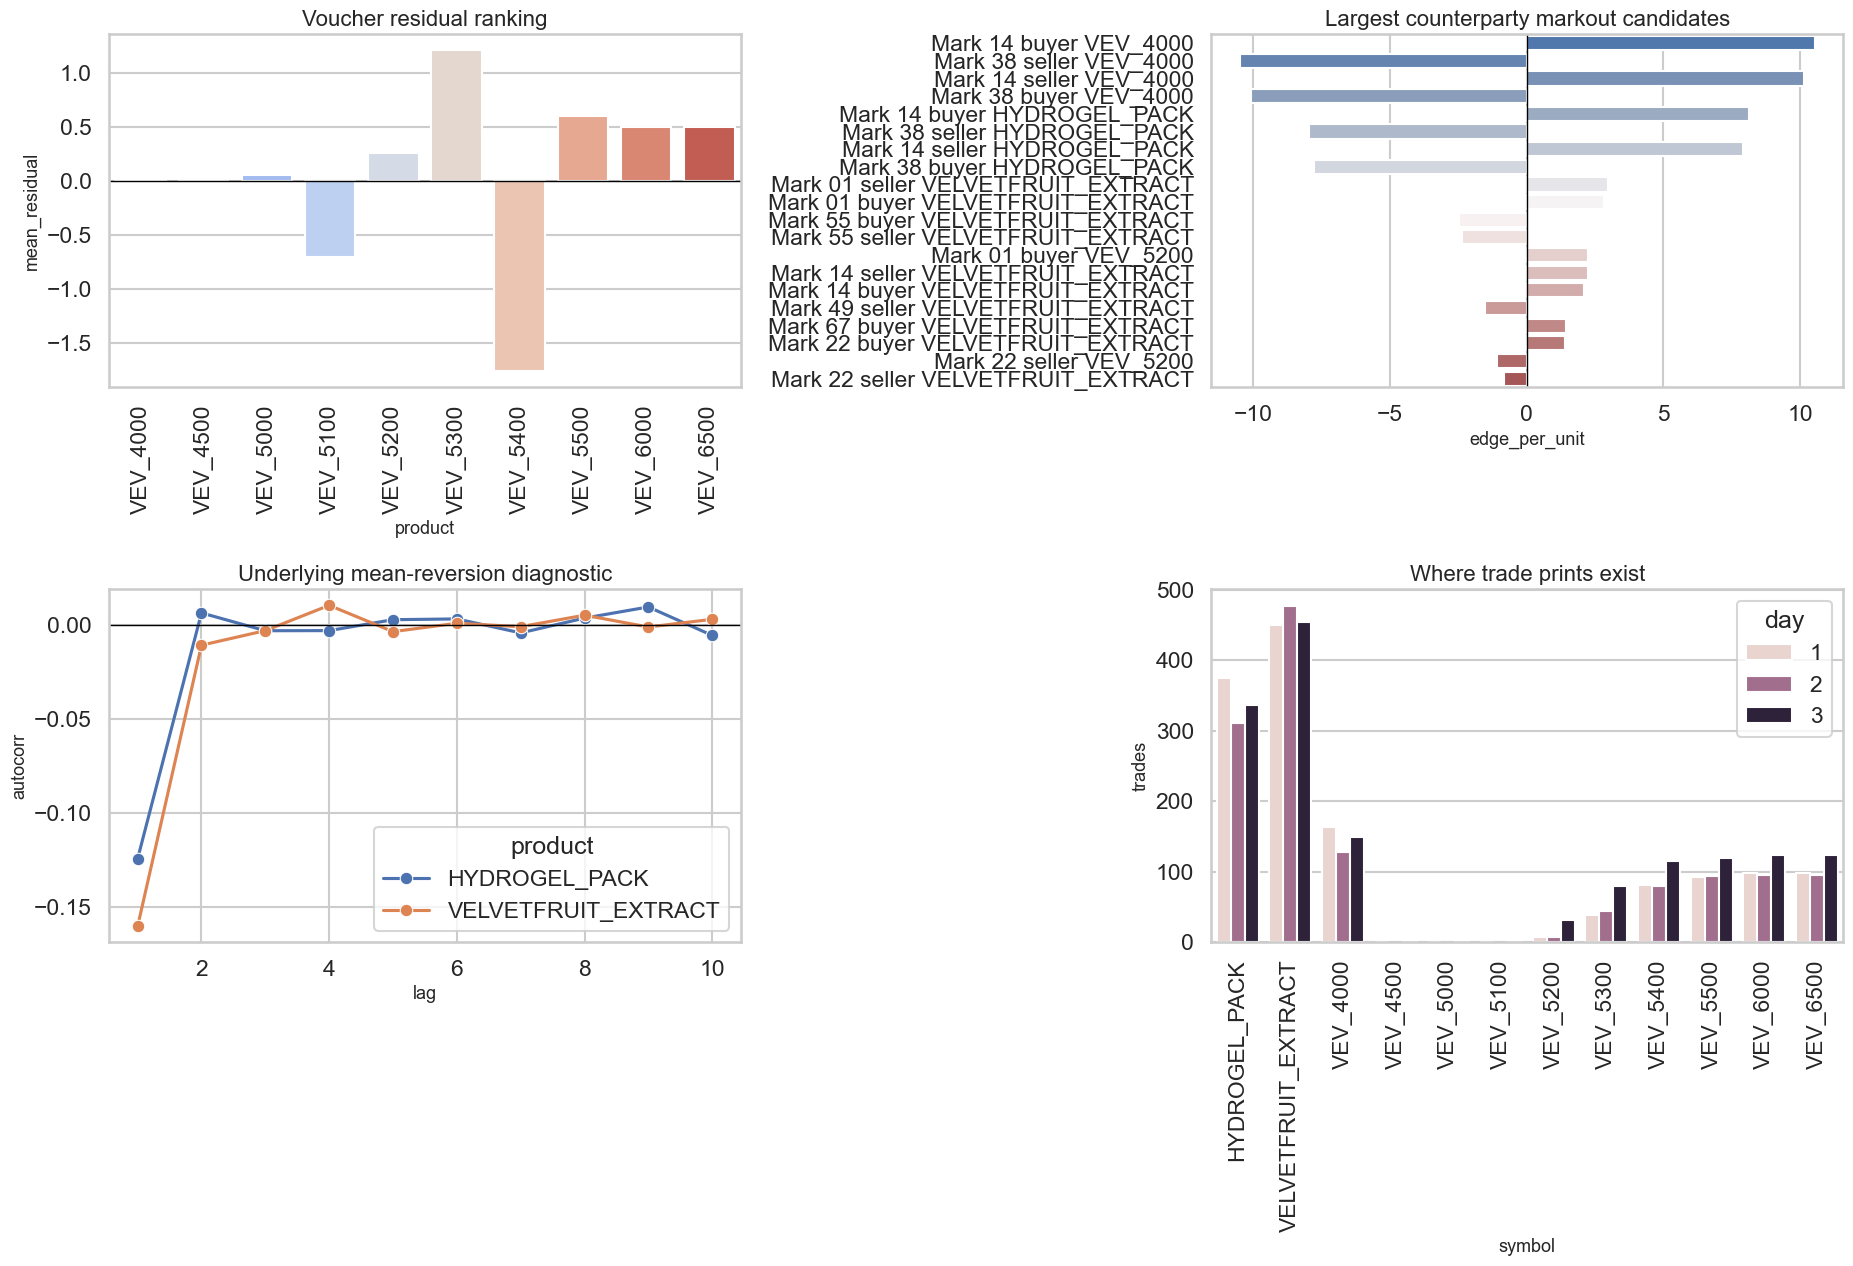

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(19, 13))

if not residual_summary.empty:
    sns.barplot(data=residual_summary.reset_index(), x="product", y="mean_residual", palette="coolwarm", ax=axes[0, 0])
    axes[0, 0].axhline(0, color="black", linewidth=1)
    axes[0, 0].set_title("Voucher residual ranking")
    axes[0, 0].tick_params(axis="x", rotation=90)

strong_edges = edge_summary_1000[edge_summary_1000["trades"] >= 5].copy()
strong_edges["label"] = strong_edges["participant"] + " " + strong_edges["side"] + " " + strong_edges["symbol"]
strong_edges = strong_edges.sort_values("edge_per_unit", key=lambda x: x.abs(), ascending=False).head(20)
sns.barplot(data=strong_edges, y="label", x="edge_per_unit", palette="vlag", ax=axes[0, 1])
axes[0, 1].axvline(0, color="black", linewidth=1)
axes[0, 1].set_title("Largest counterparty markout candidates")
axes[0, 1].set_ylabel("")

sns.lineplot(data=autocorr_df, x="lag", y="autocorr", hue="product", marker="o", ax=axes[1, 0])
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title("Underlying mean-reversion diagnostic")

sns.barplot(data=trade_counts, x="symbol", y="trades", hue="day", ax=axes[1, 1])
axes[1, 1].set_title("Where trade prints exist")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
savefig("round4_signal_dashboard.png")
plt.show()


## Actionable Next Steps For `trader.py`

1. Keep the Round 3 baseline blocks for the two underlyings and the voucher surface model. Round 4 did not introduce new products; it introduced named counterparties.
2. Add a counterparty memory layer: store the last few `market_trades` by `participant`, `side`, `product`, and timestamp.
3. Use a small fair-value adjustment after strong participant-side prints. Start with only the top few high-sample, high-edge entries from `round4_counterparty_markout_edges.csv`.
4. Do not blindly follow every Mark. Gate by product and minimum historical count. A Mark can be good in one product and noise in another.
5. Treat vouchers through relative value, not raw price. Use `VELVETFRUIT_EXTRACT` as the state variable, fit a lightweight volatility/surface approximation, and trade only residuals with a buffer.
6. Keep risk controls tighter than Round 3 for vouchers. Counterparty signals can create clustered inventory; cap exposure per strike and avoid carrying large short gamma into the close.

The two files most directly useful for implementation are:

- `round_4/analysed/round4_counterparty_markout_edges.csv`
- `round_4/analysed/round4_signal_candidates.csv`
